#Projeto de Análise de dados e Machine Learning - Predição de vitórias dos mandantes no campeonato brasileiro e ...

**Responsáveis: Guilherme Torres do Ó e Rikelme Sousa de Carvalho**

**Dataset:** [Campeonato Brasileiro de futebol](https://www.kaggle.com/datasets/adaoduque/campeonato-brasileiro-de-futebol) (Kaggle)

**Objetivo:** construir um modelo de classificação capaz de prever se ...

Este notebook segue a estrutura pedida na entrega do Dojo:

-Análise exploratória de dados;

-Limpeza e engenharia de atributos;

-Identificação das melhores variáveis;

-Divisão treino/teste;

-Aplicação de algoritmos de ML;

-Métricas de avaliação;

-Hyperparameter tuning.

> Escolhemos o dataset Campeonato Brasileiro de futebol entre os sugeridos porque ele combina variáveis numéricas e categóricas, tem dados faltantes reais (bom exercício de tratamento) e permite criar novas features (como título extraído do nome).

## 1. Carregamento do dataset e importações

Usamos o arquivo `campeonato-brasileiro-full.csv` do dataset Campeonato Brasileiro de futebol, que contém os jogos do campeonato brasileiro de 2003 a 2025. É este arquivo que usamos para treinar e validar o modelo.

Conexão com o drive:

In [181]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Importação das bibliotecas:

In [182]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

Importação do dataset:

In [183]:
df = pd.read_csv('https://raw.githubusercontent.com/RikelmeSousadeCarvalho/ModelagemPreditivaBrasileirao/refs/heads/main/campeonato-brasileiro-full.csv')

Visualização das colunas do dataset:

In [184]:
df

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9160,9160,38,07/12/2025,16:04,Santos,Cruzeiro,4-2-3-1,4-2-3-1,J. Vojvoda,T. Tite,Santos,"Estádio Urbano Caldeira, Santos",3,0,SP,MG,743978.75
9161,9161,38,07/12/2025,16:04,Sport,Gremio,5-4-1,4-2-3-1,C. de Lucena,L. Castro,Gremio,"Adelmar da Costa Carvalho, Recife",0,4,PE,RS,88755.00
9162,9163,38,07/12/2025,16:04,Botafogo-RJ,Fortaleza,4-2-3-1,4-4-2,Davide Ancelotti,Martin Palermo,Botafogo-RJ,"Estádio Nilton Santos, Rio de Janeiro",4,2,RJ,CE,905640.00
9163,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52


Mostrar informações importantes(quantidade de linhas totais e quantidade de colunas do dataset):

In [185]:
df.shape

(9165, 17)

Tipos das variáveis do dataset, quantidade nula/não nula de cada uma delas:

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9165 entries, 0 to 9164
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  9165 non-null   int64  
 1   rodata              9165 non-null   int64  
 2   data                9165 non-null   object 
 3   hora                9165 non-null   object 
 4   mandante            9165 non-null   object 
 5   visitante           9165 non-null   object 
 6   formacao_mandante   4190 non-null   object 
 7   formacao_visitante  4190 non-null   object 
 8   tecnico_mandante    4555 non-null   object 
 9   tecnico_visitante   4555 non-null   object 
 10  vencedor            9165 non-null   object 
 11  arena               9165 non-null   object 
 12  mandante_Placar     9165 non-null   int64  
 13  visitante_Placar    9165 non-null   int64  
 14  mandante_Estado     9165 non-null   object 
 15  visitante_Estado    9165 non-null   object 
 16  arreca

In [187]:
# Ainda entendendo os tipos das colunas
df.dtypes

,0
ID,int64
rodata,int64
data,object
hora,object
mandante,object
visitante,object
formacao_mandante,object
formacao_visitante,object
tecnico_mandante,object
tecnico_visitante,object


Estatísticas descritivas das variáveis numéricas:

In [188]:
df.describe()

,ID,rodata,mandante_Placar,visitante_Placar,arrecadacao
count,9165.000000,9165.000000,9165.000000,9165.000000,3.800000e+02
mean,4583.000000,20.080742,1.535188,1.026077,1.363330e+06
std,2645.851942,11.407037,1.226254,1.025470,1.158877e+06
min,1.000000,1.000000,0.000000,0.000000,6.187500e+04
25%,2292.000000,10.000000,1.000000,0.000000,4.731792e+05
50%,4583.000000,20.000000,1.000000,1.000000,9.962582e+05
75%,6874.000000,30.000000,2.000000,2.000000,1.916168e+06
max,9165.000000,46.000000,8.000000,7.000000,5.983920e+06


 Estatísticas descritivas das variáveis categóricas:

In [189]:
df.describe(include=["object"])

,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Estado,visitante_Estado
count,9165,9165,9165,9165,4190,4190,4555,4555,9165,9165,9165,9165
unique,2162,194,46,46,22,21,268,274,47,191,15,15
top,06/07/2008,16:00,Fluminense,Flamengo,4-2-3-1,4-2-3-1,L. Venker de Menezes,L. Venker de Menezes,-,Maracanã,SP,SP
freq,15,1963,447,448,2414,2266,141,144,2421,669,2287,2287


**Dicionário de variáveis (resumo):**

| Coluna | Descrição |
|---|---|
| ID / rodata / data / hora | Identificadores, exigem tratamento especial antes de virarem features úteis |
| mandante / visitante | Representam se o time jogou em casa ou fora de casa |
| formacao_mandante / formacao_visitante | Formação em que o time foi escalado para o jogo |
| tecnico_mandante / tecnico_visitante | Nome do técnico do time na partida em questão |
| vencedor | Time ganhador da partida. (-) significa empate |
| arena | Arena onde foi realizado o jogo |
| mandante_Placar / visitante_Placar | Quantidade de gols alcançada por cada time |
| mandante_Estado / visitante_Estado | Estado de origem de cada time |
| arrecadacao | Quantidade de dinheiro arrecadada pelo time mandante no jogo |


## 2. Análise de valores faltantes

Antes de qualquer modelagem, é essencial entender onde há dados faltantes, pois isso influencia diretamente as decisões de limpeza.

In [190]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"faltantes": missing, "% do total": missing_pct})[missing > 0]

,faltantes,% do total
arrecadacao,8785,95.85
formacao_mandante,4975,54.28
formacao_visitante,4975,54.28
tecnico_visitante,4610,50.30
tecnico_mandante,4610,50.30


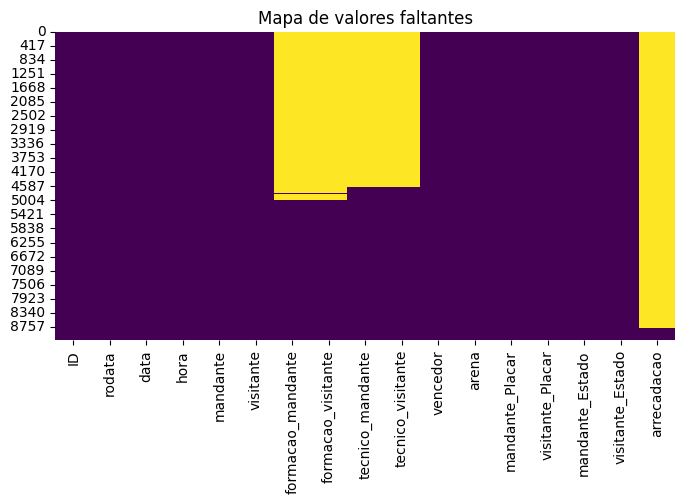

In [191]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.show()

**Observações:** TENHO QUE REVISAR ESSA PARTE ADICIONANDO "AS PROVAS" ACIMA
- `arrecadacao` tem ~96% de valores faltantes — posteriormente descobrimos que todos os valores que estão no dataset correspondem a temporada 2025. Ou seja, temos a arrecadação de cada jogo do Brasileirão 2025, apenas.
- `formacao_mandante / formacao_visitante` tem ~54% de faltantes. Na temporada 2025 esses dados estão completos.
- `tecnico_mandante / tecnico_visitante` tem ~50% valores faltantes.

Quantas colunas vazias tem o Rio de Janeiro:

In [192]:
df_rio = df.loc[df['mandante_Estado'] =='RJ']
df_rio.isna().sum()

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,892
formacao_visitante,892
tecnico_mandante,834
tecnico_visitante,834


Quantas colunas vazias tem SP:

In [193]:
df_sp = df.loc[df['mandante_Estado'] == 'SP']
df_sp.isna().sum()

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,1277
formacao_visitante,1277
tecnico_mandante,1205
tecnico_visitante,1205


Limpando todas as linhas nulas do dataset. **Observação:** descobri que as linhas não nulas correspondem a temporada 2025!


In [194]:
df_free = df.dropna()
df_free

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
8785,8786,1,29/03/2025,18:30,Juventude,Vitoria,4-2-3-1,4-2-3-1,M. Barbieri,J. Ventura,Juventude,"Alfredo Jaconi, Caxias do Sul",2,0,RS,BA,220000.00
8786,8787,1,29/03/2025,18:30,Fortaleza,Fluminense,3-4-3,4-3-3,T. Carpini,L. Luis Zubeldia,Fortaleza,"Arena Castelão, Fortaleza",2,0,CE,RJ,267643.00
8787,8790,1,29/03/2025,18:31,Cruzeiro,Mirassol,4-2-2-2,4-2-3-1,T. Tite,R. Guanaes,Cruzeiro,"Mineirão, Belo Horizonte",2,1,MG,SP,2089452.00
8788,8788,1,29/03/2025,18:32,Gremio,Atletico-MG,4-2-3-1,4-4-2,L. Castro,J. Sampaoli,Gremio,"Arena do Grêmio, Porto Alegre",2,1,RS,MG,1175509.00
8789,8789,1,29/03/2025,18:32,Sao Paulo,Sport,3-4-1-2,4-3-1-2,H. Crespo,C. de Lucena,-,"MorumBIS, São Paulo",0,0,SP,PE,2144747.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9160,9160,38,07/12/2025,16:04,Santos,Cruzeiro,4-2-3-1,4-2-3-1,J. Vojvoda,T. Tite,Santos,"Estádio Urbano Caldeira, Santos",3,0,SP,MG,743978.75
9161,9161,38,07/12/2025,16:04,Sport,Gremio,5-4-1,4-2-3-1,C. de Lucena,L. Castro,Gremio,"Adelmar da Costa Carvalho, Recife",0,4,PE,RS,88755.00
9162,9163,38,07/12/2025,16:04,Botafogo-RJ,Fortaleza,4-2-3-1,4-4-2,Davide Ancelotti,Martin Palermo,Botafogo-RJ,"Estádio Nilton Santos, Rio de Janeiro",4,2,RJ,CE,905640.00
9163,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52


## 3. Análise Exploratória de Dados


### 3.1 Distribuição da variável alvo (vencedor)

### 3.2 Testes de curiosidade sobre os times que os responsáveis torcem

Ver jogos do palmeiras (criamos um data frame que mostra só os jogos do Palmeiras):

In [195]:
df_pal = df.loc[(df['mandante'] == 'Palmeiras') | (df['visitante'] == 'Palmeiras')]
df_pal

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
556,557,1,21/04/2004,18:00,Palmeiras,Atletico-MG,NaN,NaN,NaN,NaN,-,Parque Antártica,0,0,SP,MG,NaN
567,568,2,25/04/2004,16:00,Internacional,Palmeiras,NaN,NaN,NaN,NaN,Internacional,Beira Rio,1,0,RS,SP,NaN
586,587,3,29/04/2004,20:30,Palmeiras,Vitoria,NaN,NaN,NaN,NaN,-,Parque Antártica,2,2,SP,BA,NaN
594,596,4,02/05/2004,16:00,Corinthians,Palmeiras,NaN,NaN,NaN,NaN,Palmeiras,Morumbi,0,4,SP,SP,NaN
604,606,5,08/05/2004,18:00,Palmeiras,Ponte Preta,NaN,NaN,NaN,NaN,Palmeiras,Parque Antártica,3,0,SP,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9120,9117,37,19/11/2025,19:30,Palmeiras,Vitoria,4-2-3-1,3-4-2-1,A. Ferreira,J. Ventura,-,"Allianz Parque, São Paulo",0,0,SP,BA,2632317.00
9126,9137,35,22/11/2025,21:30,Palmeiras,Fluminense,4-4-2,4-2-3-1,A. Ferreira,L. Luis Zubeldia,-,"Allianz Parque, São Paulo",0,0,SP,RJ,2986721.80
9135,9147,36,25/11/2025,21:30,Gremio,Palmeiras,4-2-3-1,4-2-3-1,L. Castro,A. Ferreira,Gremio,"Arena do Grêmio, Porto Alegre",3,2,RS,SP,1314249.00
9148,9135,34,03/12/2025,21:30,Atletico-MG,Palmeiras,3-4-2-1,4-2-3-1,J. Sampaoli,A. Ferreira,Palmeiras,"Arena MRV, Belo Horizonte",0,3,MG,SP,535000.17


Quantos jogos o Palmeiras teve nesse período?

In [196]:
df_pal.shape

(810, 17)

Quantas vezes o palmeiras ganhou nesse período?

In [197]:
df_palGanhador = df_pal['vencedor'] == 'Palmeiras'
(df_palGanhador == True).sum()

np.int64(374)

Ver jogos do Corinthians (df que mostra só os jogos do Corinthians):

In [198]:
df_cor = df.loc[(df['mandante'] == 'Corinthians') | (df['visitante'] == 'Corinthians')]
df_cor

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
11,12,1,30/03/2003,18:00,Corinthians,Atletico-MG,NaN,NaN,NaN,NaN,Atletico-MG,Pacaembu,0,3,SP,MG,NaN
17,18,2,06/04/2003,16:00,Figueirense,Corinthians,NaN,NaN,NaN,NaN,-,Orlando Scarpelli,3,3,SC,SP,NaN
28,40,3,12/04/2003,18:00,Corinthians,Paysandu,NaN,NaN,NaN,NaN,Corinthians,Pacaembu,6,1,SP,PA,NaN
43,32,4,16/04/2003,21:40,Vasco,Corinthians,NaN,NaN,NaN,NaN,-,São Januário,2,2,RJ,SP,NaN
53,53,5,20/04/2003,16:00,Internacional,Corinthians,NaN,NaN,NaN,NaN,Internacional,Beira Rio,2,1,RS,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9123,9132,34,20/11/2025,19:30,Corinthians,Sao Paulo,4-4-2,3-5-2,D. Junior,H. Crespo,Corinthians,"Neo Química Arena, São Paulo",3,1,SP,SP,3539617.2
9131,9142,35,23/11/2025,20:34,Cruzeiro,Corinthians,4-2-3-1,5-3-2,T. Tite,D. Junior,Cruzeiro,"Mineirão, Belo Horizonte",3,0,MG,SP,1637835.5
9144,9155,36,30/11/2025,16:00,Corinthians,Botafogo-RJ,4-1-2-1-2,4-2-3-1,Dorival Silvestre Junior,Davide Ancelotti,-,"Neo Química Arena, São Paulo",2,2,SP,RJ,2694558.5
9149,9120,37,03/12/2025,19:03,Fortaleza,Corinthians,4-2-3-1,4-3-3,T. Carpini,D. Junior,Fortaleza,"Arena Castelão, Fortaleza",2,1,CE,SP,1433088.0


Jogos do Corinthians no período:

In [199]:
df_cor.shape

(856, 17)

Vitórias do Corinthians no período:

In [200]:
df_corGanhador = df_cor['vencedor'] == 'Corinthians'
(df_corGanhador == True).sum()

np.int64(353)

Histórico do Dérbi: Retrospecto de Corinthians X Palmeiras em confrontos diretos pelo Brasileirão:

Total de jogos: 40
Vitórias Corinthians: 12 (30.0%)
Vitórias Palmeiras: 17 (42.5%)
Empates: 11 (27.5%)


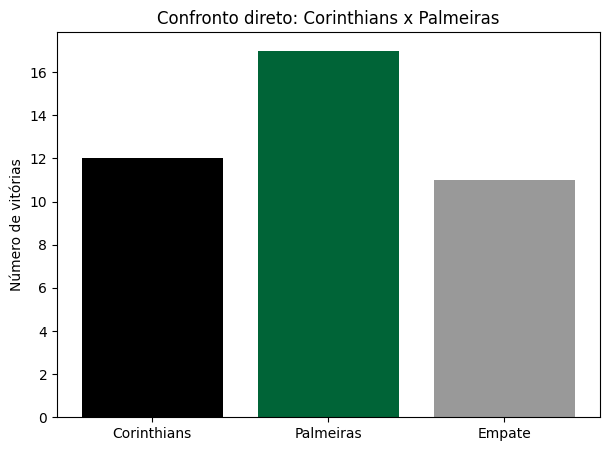

In [201]:
confronto = df[
    ((df["mandante"] == "Corinthians") & (df["visitante"] == "Palmeiras")) |
    ((df["mandante"] == "Palmeiras") & (df["visitante"] == "Corinthians"))
]

vitorias_corinthians = (confronto["vencedor"] == "Corinthians").sum()
vitorias_palmeiras = (confronto["vencedor"] == "Palmeiras").sum()
empates = (confronto["vencedor"] == "-").sum()
total = len(confronto)

print(f"Total de jogos: {total}")
print(f"Vitórias Corinthians: {vitorias_corinthians} ({vitorias_corinthians/total*100:.1f}%)")
print(f"Vitórias Palmeiras: {vitorias_palmeiras} ({vitorias_palmeiras/total*100:.1f}%)")
print(f"Empates: {empates} ({empates/total*100:.1f}%)")

plt.figure(figsize=(7, 5))
plt.bar(["Corinthians", "Palmeiras", "Empate"], [vitorias_corinthians, vitorias_palmeiras, empates], color=['#000000', '#006437', '#999999'])
plt.title("Confronto direto: Corinthians x Palmeiras")
plt.ylabel("Número de vitórias")
plt.show()

### 3.3 Relações de arrecadação

Buscamos estabelecer uma relação entre o Estado do time mandante e a arrecadação entre os 4 Estados brasileiros mais tradicionais no futebol nacional

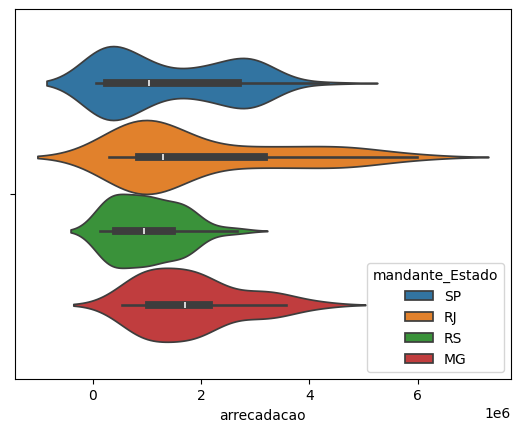

In [202]:
estados = ['RJ', 'SP', 'MG', 'RS']
df_filtered = df[df['mandante_Estado'].isin(estados)]
g = sns.violinplot(data = df_filtered, x = 'arrecadacao', hue='mandante_Estado')

Outro grafico, dessa vez mostrando arrecadação total por cada Estado

<Axes: xlabel='mandante_Estado', ylabel='arrecadacao'>

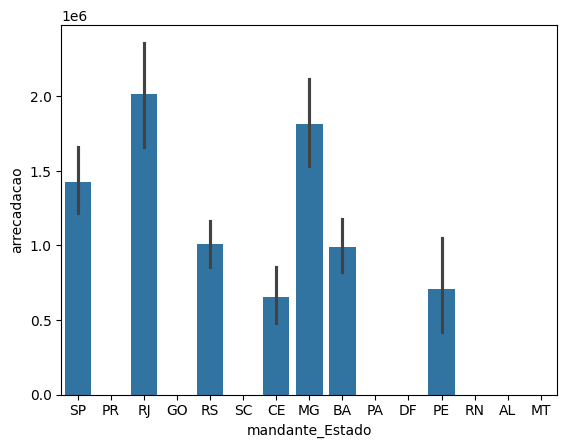

In [203]:
gb = sns.barplot(data = df, x = 'mandante_Estado', y = 'arrecadacao')
gb

Qual time de SP arrecadou mais dinheiro:

In [204]:
df_sp.groupby('mandante')['arrecadacao'].sum().sort_values(ascending = False)

,arrecadacao
mandante,
Corinthians,54079722.40
Palmeiras,47680681.00
Sao Paulo,28598317.50
Santos,21513965.04
Mirassol,7427960.00
Bragantino,3494345.00
Guarani,0.00
Barueri,0.00
Gremio Prudente,0.00


Qual time do rio arrecadou mais dinheiro:

In [205]:
df_rio.groupby('mandante')['arrecadacao'].sum().sort_values(ascending = False)

,arrecadacao
mandante,
Flamengo,81773984.0
Vasco,30996515.5
Fluminense,24651439.5
Botafogo-RJ,15519520.0


Buscando uma correlação em quantos gols o mandante marcou e quanto foi arrecadado. Isso pode ser um indicativo que o apoio da torcida faz com que o time marque mais gols. **Observação: correlação forte!**

In [206]:
correlacao = df["mandante_Placar"].corr(df["arrecadacao"])
correlacao

np.float64(0.07586792397311544)

Queremos testar se quando o jogo é interestadual tem mais ou menos arrecadação que a média. **Constatação: Em jogos interestaduais a média de arrecadação é maior!**

In [207]:
df['interestadual'] = df['mandante_Estado'] == df['visitante_Estado']
mediaArrInterEst = df.groupby('interestadual')['arrecadacao'].mean()
mediaArrInterEst

,arrecadacao
interestadual,
False,1.300466e+06
True,1.742840e+06


### 3.4 Relações de número de gols

Calculando a média de gols por rodada na temporada 2025 pra ver se existe alguma relação

/tmp/ipykernel_310/2601382124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free["totalGols"] = df_free["mandante_Placar"] + df_free["visitante_Placar"]


<Axes: xlabel='rodata'>

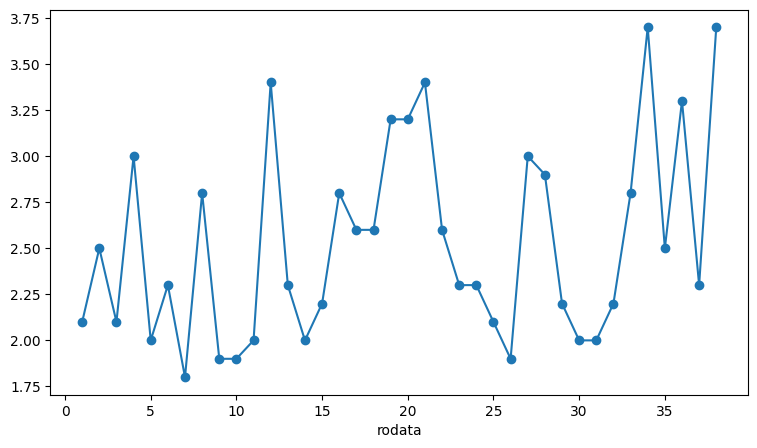

In [208]:
df_free["totalGols"] = df_free["mandante_Placar"] + df_free["visitante_Placar"]

media_por_rodada = df_free.groupby("rodata")["totalGols"].mean()
media_por_rodada.plot(kind="line", marker="o", figsize=(9, 5))

Calculando a média de gols por rodada em todo o dataset pra ver se existe alguma relação


/tmp/ipykernel_310/3245401302.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["data"] = pd.to_datetime(df["data"])


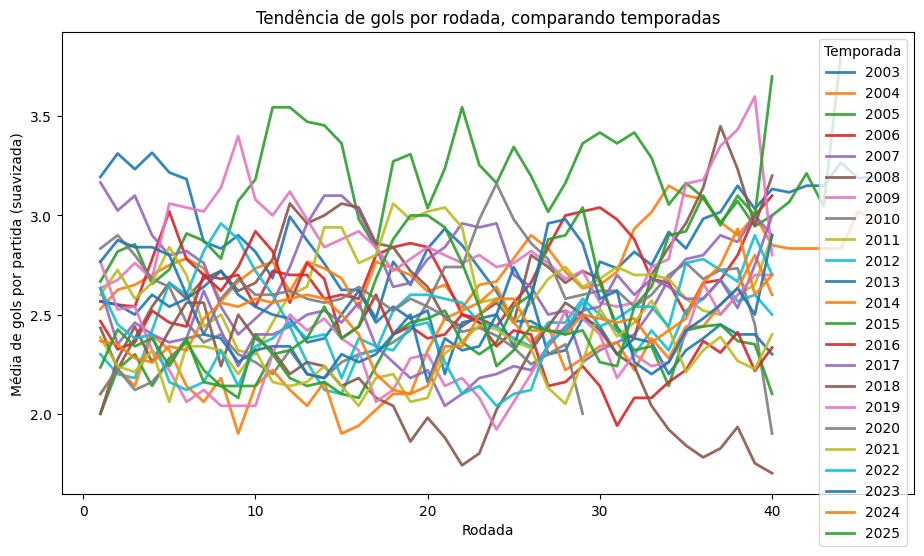

In [209]:
df["data"] = pd.to_datetime(df["data"])
df["temporada"] = df["data"].dt.year
df["totalGols"] = df["mandante_Placar"] + df["visitante_Placar"]

media = df.groupby(["temporada", "rodata"])["totalGols"].mean()
media = media.unstack(level="temporada")
suavizado = media.rolling(window=5, min_periods=1, center=True).mean()

plt.figure(figsize=(11, 6))
for temporada in suavizado.columns:
    plt.plot(suavizado.index, suavizado[temporada], linewidth=2, alpha=0.9, label=str(temporada))

plt.xlabel("Rodada")
plt.ylabel("Média de gols por partida (suavizada)")
plt.title("Tendência de gols por rodada, comparando temporadas")
plt.legend(title="Temporada")
plt.show()

Distribuição por partidas: qual a média de gols do campeonato? !Média de 2.52 gols por jogo em 2025!

In [210]:
soma_mandante = df_free['mandante_Placar'].sum()
soma_visitante = df_free['visitante_Placar'].sum()
media_gols = (soma_mandante + soma_visitante) / len(df_free)
media_gols


np.float64(2.5236842105263158)

Como a média de gols variou ao longo do tempo? Pegando o dataset inteiro(méedia total de gols em todo o tempo do dataset)

In [211]:
totalGols = (df['mandante_Placar'] + df['visitante_Placar']).sum()
totalGols
df['mediaGols'] = df['mandante_Placar'] + df['visitante_Placar']
df['mediaGols'].mean()


np.float64(2.56126568466994)

Queremos testar se quando o jogo é interestadual tem mais ou menos gols que a média. **Constatação: Em jogos interestaduais sai menos gols, provavelmente porque os jogos são mais físicos(mais brigados)!**

In [212]:
df['interestadual'] = df['mandante_Estado'] == df['visitante_Estado']
mediaArrInterEst = df.groupby('interestadual')['mediaGols'].mean()
mediaArrInterEst

,mediaGols
interestadual,
False,2.577970
True,2.421107


In [213]:
df_palGanhador = df_pal['vencedor'] == 'Palmeiras'
(df_palGanhador == True).sum()

np.int64(374)

### 3.5 Relações entre formações táticas

Queremos testar a relação entre as formações e as taxas de vitórias no brasileirão de 2025 - DESCOBRIMOS AS FORMAÇÕES MAIS VENCEDORAS ENTRE OS MANDANTES, MAS NÃO SABEMOS QUANTAS VEZES USARAM ESSA FORMAÇÃO. **Constatação: observamos que a maioria são mais ofensivas!**

/tmp/ipykernel_310/1728724354.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['vitoria_mandante'] = df_free['vencedor'] == df_free['mandante']


<Axes: xlabel='vitoria_mandante', ylabel='formacao_mandante'>

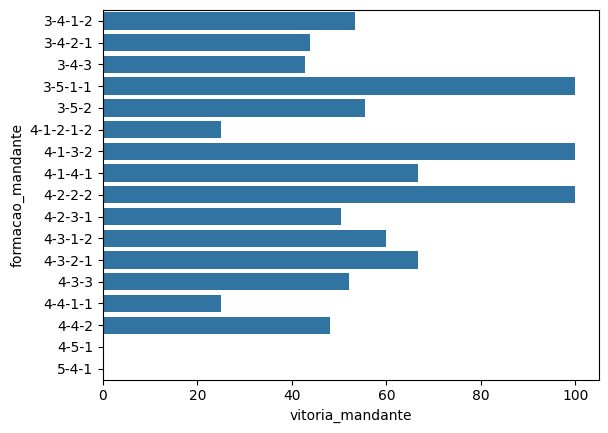

In [214]:
df_free['vitoria_mandante'] = df_free['vencedor'] == df_free['mandante']

#calcula a taxa de aproveitamento (%) por formação
taxaAproveitamento = (df_free.groupby('formacao_mandante')['vitoria_mandante'].mean() * 100)

sns.barplot(data=taxaAproveitamento.reset_index(), x='vitoria_mandante', y='formacao_mandante')

Queremos testar a relação entre as formações e as taxas de vitórias no brasileirão de 2025 - DESCOBRIMOS AS FORMAÇÕES MAIS VENCEDORAS ENTRE OS VISITANTES, MAS NÃO SABEMOS QUANTAS VEZES USARAM ESSA FORMAÇÃO. **Constatação: observamos que a maioria são mais conservadoras!**

/tmp/ipykernel_310/3588613244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['vitoria_visitante'] = df_free['vencedor'] == df_free['visitante']


<Axes: xlabel='vitoria_visitante', ylabel='formacao_visitante'>

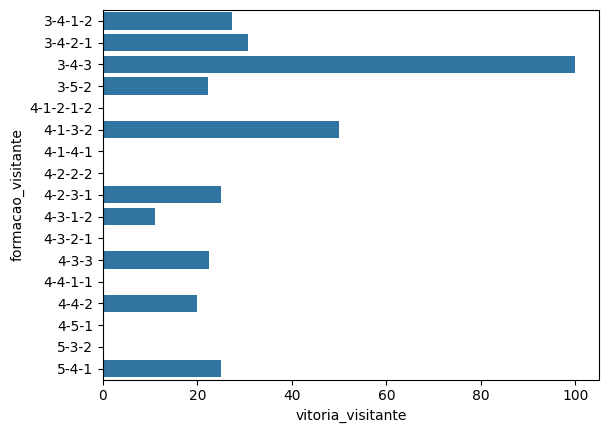

In [215]:
df_free['vitoria_visitante'] = df_free['vencedor'] == df_free['visitante']

#calcula a taxa de aproveitamento (%) por formação
taxaAproveitamento = (df_free.groupby('formacao_visitante')['vitoria_visitante'].mean() * 100)

sns.barplot(data=taxaAproveitamento.reset_index(), x='vitoria_visitante', y='formacao_visitante')

### 3.6 Relações de mando de campo

Buscando entender se o Rio tem jogos a mais que SP

In [216]:
df_rio = df.loc[df['mandante_Estado'] =='RJ']
df_rio

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,interestadual,temporada,totalGols,mediaGols
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,...,Maracanã,1,1,RJ,PR,NaN,False,2003,2,2
12,13,2,2003-04-05,16:00,Fluminense,Fortaleza,NaN,NaN,NaN,NaN,...,Maracanã,1,1,RJ,CE,NaN,False,2003,2,2
23,24,2,2003-04-06,18:00,Vasco,Goias,NaN,NaN,NaN,NaN,...,São Januário,6,4,RJ,GO,NaN,False,2003,10,10
36,48,3,2003-04-13,18:00,Flamengo,Fluminense,NaN,NaN,NaN,NaN,...,Maracanã,4,1,RJ,RJ,NaN,True,2003,5,5
43,32,4,2003-04-16,21:40,Vasco,Corinthians,NaN,NaN,NaN,NaN,...,São Januário,2,2,RJ,SP,NaN,False,2003,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9139,9151,36,2025-11-28,19:30,Vasco,Internacional,4-2-3-1,4-3-1-2,F. Diniz,R. Díaz,...,"Estádio São Januário, Rio de Janeiro",5,1,RJ,RS,1313832.0,False,2025,6,6
9145,9118,37,2025-12-02,19:01,Vasco,Mirassol,4-2-3-1,4-2-3-1,F. Diniz,R. Guanaes,...,"Estádio São Januário, Rio de Janeiro",0,2,RJ,SP,1300947.0,False,2025,2,2
9153,9124,37,2025-12-03,21:30,Flamengo,Ceara,4-2-3-1,4-2-3-1,F. Luís,M. Mozart,...,"Maracanã, Rio de Janeiro",1,0,RJ,CE,4950770.0,False,2025,1,1
9157,9157,38,2025-12-07,16:04,Fluminense,Bahia,4-2-3-1,4-3-3,L. Luis Zubeldia,R. Ceni,...,"Maracanã, Rio de Janeiro",2,0,RJ,BA,1927662.5,False,2025,2,2


In [217]:
df_sp = df.loc[df['mandante_Estado'] == 'SP']
df_sp

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,interestadual,temporada,totalGols,mediaGols
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,...,Brinco de Ouro,4,2,SP,RJ,NaN,False,2003,6,6
10,11,1,2003-03-30,18:00,Santos,Parana,NaN,NaN,NaN,NaN,...,Vila Belmiro,2,2,SP,PR,NaN,False,2003,4,4
11,12,1,2003-03-30,18:00,Corinthians,Atletico-MG,NaN,NaN,NaN,NaN,...,Pacaembu,0,3,SP,MG,NaN,False,2003,3,3
19,20,2,2003-04-06,16:00,Ponte Preta,Juventude,NaN,NaN,NaN,NaN,...,Moisés Lucarelli,1,0,SP,RS,NaN,False,2003,1,1
21,22,2,2003-04-06,16:00,Sao Caetano,Criciuma,NaN,NaN,NaN,NaN,...,Anacleto Campanella,3,2,SP,SC,NaN,False,2003,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9147,9134,34,2025-12-03,19:00,Bragantino,Vitoria,4-2-3-1,3-4-2-1,V. Mancini,J. Ventura,...,"Estádio Municipal Cicero De Souza Marques, Bra...",4,0,SP,BA,62435.00,False,2025,4,4
9151,9122,37,2025-12-03,20:00,Sao Paulo,Internacional,3-4-1-2,4-3-1-2,H. Crespo,R. Díaz,...,"Estádio Urbano Caldeira, Santos",3,0,SP,RS,392052.50,False,2025,3,3
9155,9156,38,2025-12-06,18:32,Mirassol,Flamengo,4-4-2,4-2-3-1,R. Guanaes,F. Luís,...,"Campos Maia, Mirassol",3,3,SP,RJ,1258100.00,False,2025,6,6
9159,9159,38,2025-12-07,16:04,Corinthians,Juventude,3-4-3,4-2-3-1,D. Junior,M. Barbieri,...,"Neo Química Arena, São Paulo",1,1,SP,RS,1888899.00,False,2025,2,2


Quantidade de empates na última temporada

In [218]:
df_e = df_free[df['vencedor'] == '-']
df_e

/tmp/ipykernel_310/357989964.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_e = df_free[df['vencedor'] == '-']


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,totalGols,vitoria_mandante,vitoria_visitante
8789,8789,1,29/03/2025,18:32,Sao Paulo,Sport,3-4-1-2,4-3-1-2,H. Crespo,C. de Lucena,-,"MorumBIS, São Paulo",0,0,SP,PE,2144747.0,0,False,False
8790,8791,1,29/03/2025,21:00,Flamengo,Internacional,4-4-2,4-2-3-1,F. Luís,R. Díaz,-,"Maracanã, Rio de Janeiro",1,1,RJ,RS,3150315.0,2,False,False
8791,8792,1,30/03/2025,16:01,Palmeiras,Botafogo-RJ,4-2-3-1,4-3-3,A. Ferreira,Renato Manuel Alves Paiva,-,"Allianz Parque, São Paulo",0,0,SP,RJ,2802427.7,0,False,False
8793,8794,1,30/03/2025,20:01,Bahia,Corinthians,4-2-3-1,4-3-3,R. Ceni,D. Junior,-,"Arena Fonte Nova, Salvador",1,1,BA,SP,1752529.0,2,False,False
8794,8795,1,31/03/2025,20:01,Bragantino,Ceara,4-2-3-1,4-2-3-1,V. Mancini,M. Mozart,-,"Nabizão, Bragança Paulista",2,2,SP,CE,61875.0,4,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,9154,36,29/11/2025,21:01,Ceara,Cruzeiro,4-2-3-1,4-2-3-1,M. Mozart,T. Tite,-,"Arena Castelão, Fortaleza",1,1,CE,MG,385906.0,2,False,False
9144,9155,36,30/11/2025,16:00,Corinthians,Botafogo-RJ,4-1-2-1-2,4-2-3-1,Dorival Silvestre Junior,Davide Ancelotti,-,"Neo Química Arena, São Paulo",2,2,SP,RJ,2694558.5,4,False,False
9154,9125,37,04/12/2025,19:32,Cruzeiro,Botafogo-RJ,4-2-3-1,4-2-3-1,Jose Leonardo Nunes Alves Sousa Jardim,Davide Ancelotti,-,"Mineirão, Belo Horizonte",2,2,MG,RJ,1038832.5,4,False,False
9155,9156,38,06/12/2025,18:32,Mirassol,Flamengo,4-4-2,4-2-3-1,R. Guanaes,F. Luís,-,"Campos Maia, Mirassol",3,3,SP,RJ,1258100.0,6,False,False


Mando de campo: times vencem mais jogando em casa? **Constatação: sim, ~50% de vitórias e ~24% de derrotas**

Distribuição geral de resultados:
resultado
Vitória Mandante     49.6
Empate               26.4
Vitória Visitante    23.9
Name: proportion, dtype: float64

Aproveitamento em casa x fora, por time (%):
                 aproveitamento_casa  aproveitamento_fora  diferenca
Barueri                         64.9                 21.1       43.8
Paysandu                        60.2                 16.4       43.8
Ipatinga                        52.6                  8.8       43.8
Guarani                         57.4                 17.9       39.5
Portuguesa                      55.6                 21.1       34.5
Athletico-PR                    64.4                 30.0       34.4
Joinville                       43.9                 10.5       33.4
Mirassol                        75.4                 42.1       33.3
Nautico                         50.9                 19.3       31.6
Criciuma                        52.1                 21.0       31.1
Gremio                          65.5    

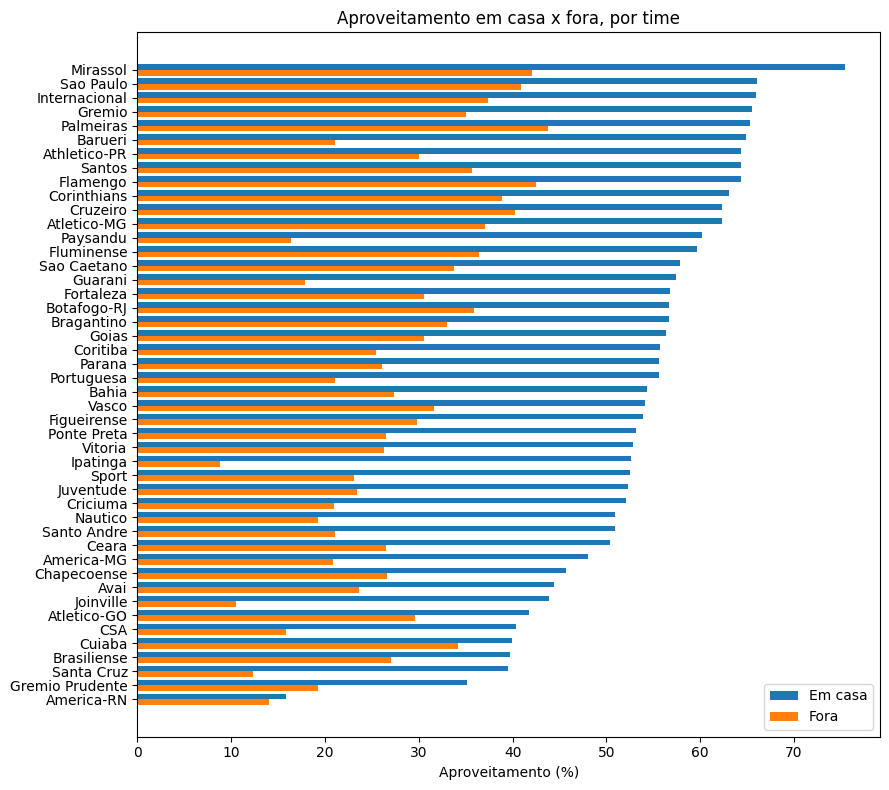

In [219]:
# 1. Cria a coluna de resultado usando a coluna "vencedor" que já existe
#    vencedor == mandante  -> Vitória Mandante
#    vencedor == visitante -> Vitória Visitante
#    vencedor == "-"       -> Empate

def resultado(row):
    if row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    elif row["vencedor"] == row["visitante"]:
        return "Vitória Visitante"
    else:
        return "Empate"

df["resultado"] = df.apply(resultado, axis=1)

# 2. Visão geral: qual % de jogos termina em cada resultado?
percentuais = df["resultado"].value_counts(normalize=True).mul(100).round(1)
print("Distribuição geral de resultados:")
print(percentuais)
print()

# 3. Visão por time: aproveitamento como mandante x como visitante
#    (vitória = 3 pts, empate = 1 pt, derrota = 0 pt)

def pontos_mandante(row):
    if row["vencedor"] == row["mandante"]:
        return 3
    elif row["vencedor"] == "-":
        return 1
    return 0

def pontos_visitante(row):
    if row["vencedor"] == row["visitante"]:
        return 3
    elif row["vencedor"] == "-":
        return 1
    return 0

df["pontos_mandante"] = df.apply(pontos_mandante, axis=1)
df["pontos_visitante"] = df.apply(pontos_visitante, axis=1)

aproveitamento_casa = (df.groupby("mandante")["pontos_mandante"].mean() / 3 * 100).round(1)
aproveitamento_fora = (df.groupby("visitante")["pontos_visitante"].mean() / 3 * 100).round(1)

comparacao = pd.DataFrame({
    "aproveitamento_casa": aproveitamento_casa,
    "aproveitamento_fora": aproveitamento_fora,
})
comparacao["diferenca"] = comparacao["aproveitamento_casa"] - comparacao["aproveitamento_fora"]
comparacao = comparacao.sort_values("diferenca", ascending=False)

print("Aproveitamento em casa x fora, por time (%):")
print(comparacao)

# 4. Gráfico de barras comparando casa x fora, por time
comparacao_plot = comparacao.sort_values("aproveitamento_casa", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
y = range(len(comparacao_plot))
ax.barh(y, comparacao_plot["aproveitamento_casa"], height=0.4, label="Em casa", color="#1f77b4", align="edge")
ax.barh([i - 0.4 for i in y], comparacao_plot["aproveitamento_fora"], height=0.4, label="Fora", color="#ff7f0e", align="edge")
ax.set_yticks(y)
ax.set_yticklabels(comparacao_plot.index)
ax.set_xlabel("Aproveitamento (%)")
ax.set_title("Aproveitamento em casa x fora, por time")
ax.legend()
plt.tight_layout()
plt.show()

Mando de campo: Qual a diferença de aproveitamento mandante x visitante?

In [220]:
# 1. Contar o número de vitórias do mandante
vitorias_mandante = (df_free['mandante'] == df_free['vencedor']).sum()

# 2. Calcular o aproveitamento em porcentagem
total_jogos = len(df_free)
aproveitamento = (vitorias_mandante / total_jogos) * 100

print(f"Vitórias em casa: {vitorias_mandante} de {total_jogos} jogos")
print(f"Aproveitamento dos mandantes: {aproveitamento:.2f}%")

Vitórias em casa: 191 de 380 jogos
Aproveitamento dos mandantes: 50.26%


/tmp/ipykernel_310/3374008281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['resultado_mandante'] = (


<Axes: xlabel='resultado_mandante', ylabel='count'>

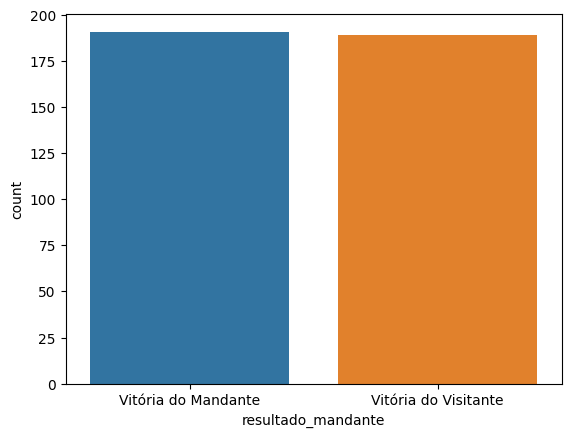

In [221]:
#Gráfico de barras do de cima
df_free['resultado_mandante'] = (
    df_free['mandante'] == df_free['vencedor']
).map({True: 'Vitória do Mandante', False: 'Vitória do Visitante'})

sns.countplot(data=df_free, x='resultado_mandante', hue='resultado_mandante', legend=False)

Existe uma tendência observada mundialmente de queda do fator casa nos últimos anos. Será que esse padrão aparece no Brasileirão?

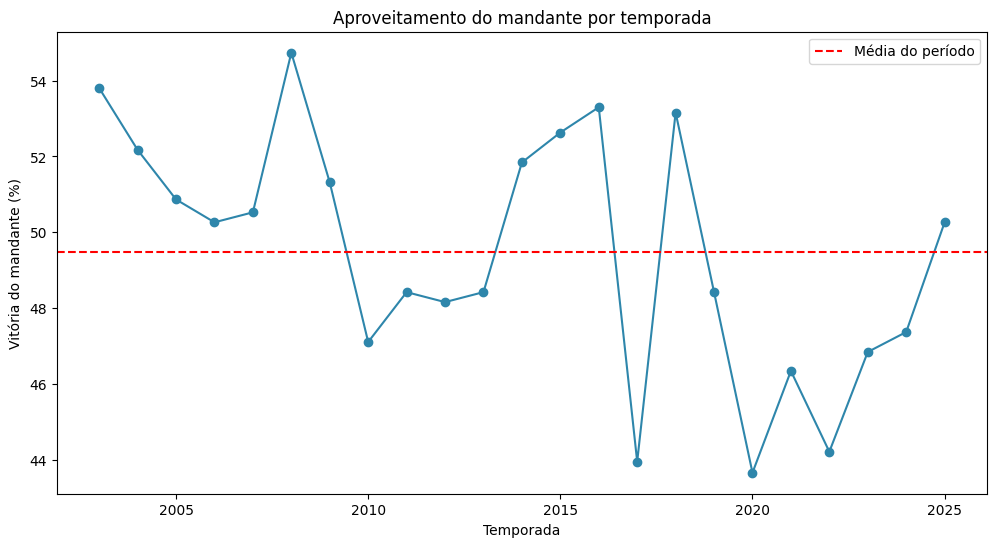

In [222]:
df["data"] = pd.to_datetime(df["data"])
df["temporada"] = df["data"].dt.year

def resultado(row):
    if row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    elif row["vencedor"] == row["visitante"]:
        return "Vitória Visitante"
    else:
        return "Empate"

df["resultado"] = df.apply(resultado, axis=1)

aproveitamento_temporada = (
    df.groupby("temporada")["resultado"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

plt.figure(figsize=(12, 6))
plt.plot(aproveitamento_temporada.index, aproveitamento_temporada["Vitória Mandante"], marker='o', color='#2E86AB')
plt.axhline(y=aproveitamento_temporada["Vitória Mandante"].mean(), color='red', linestyle='--', label='Média do período')
plt.title("Aproveitamento do mandante por temporada")
plt.xlabel("Temporada")
plt.ylabel("Vitória do mandante (%)")
plt.legend()
plt.show()

**Constatação:** O aproveitamento do mandante oscila bastante ano a ano, sem uma tendência linear clara de queda, diferente do padrão observado em estudos globais. Uma hipótese é que essa queda mundial reflete uma transição mais lenta e antiga do futebol moderno (profissionalização de equipes visitantes, melhor preparo tático fora de casa), que já pode ter ocorrido majoritariamente antes do período coberto pelo dataset (2003-2025), restando aqui principalmente oscilação natural entre temporadas.

Como visto, o mandante vence ~50% das partidas no geral. Verificando se esse aproveitamento varia por estado:

mandante_Estado
RS    54.921260
SP    53.651071
MG    52.471083
PA    52.238806
PR    51.570048
RJ    50.122549
BA    44.558522
CE    44.252874
PE    42.382271
GO    42.058166
SC    39.273927
AL    31.578947
MT    28.947368
DF    28.571429
RN    10.526316
Name: resultado, dtype: float64
mandante_Estado
SP    2287
RJ    1632
RS    1016
MG     951
PR     828
SC     606
BA     487
GO     447
PE     361
CE     348
MT      76
PA      67
DF      21
AL      19
RN      19
dtype: int64


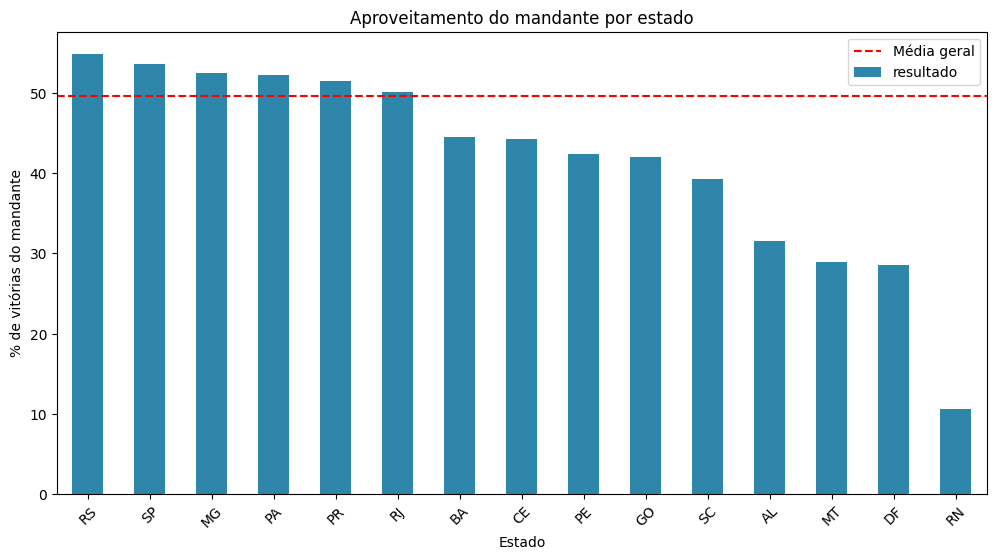

In [223]:
aproveitamento_estado = (
    df.groupby("mandante_Estado")["resultado"]
    .apply(lambda x: (x == "Vitória Mandante").mean() * 100)
    .sort_values(ascending=False)
)

print(aproveitamento_estado)

# Quantidade de jogos por estado, pra saber se o % é confiável
print(df.groupby("mandante_Estado").size().sort_values(ascending=False))

plt.figure(figsize=(12, 6))
aproveitamento_estado.plot(kind='bar', color='#2E86AB')
plt.axhline(y=(df["resultado"] == "Vitória Mandante").mean() * 100, color='red', linestyle='--', label='Média geral')
plt.title('Aproveitamento do mandante por estado')
plt.xlabel('Estado')
plt.ylabel('% de vitórias do mandante')
plt.legend()
plt.xticks(rotation=45)
plt.show()

**Constatação:** Estados com grande volume de jogos (SP, RJ, RS, MG, PR) têm aproveitamento do mandante acima da média geral (50-55%), indicando um fator casa mais forte nesses estados — provavelmente ligado a clubes tradicionais e torcidas maiores. Já BA, CE, PE, GO e SC ficam abaixo da média (~39-44%), mas ainda com volume razoável de jogos (350-600), sugerindo um fator casa real, porém mais fraco. Os extremos (RN, DF, AL) têm poucos jogos como mandante (19-21), então o percentual ali reflete mais o tamanho pequeno da amostra do que um padrão real.

### 3.7 Relações de calendário

A distribuição de resultados muda dependendo do dia da semana em que o jogo acontece? **Constatação: não há padrão relevante entre dia da semana e resultado.**

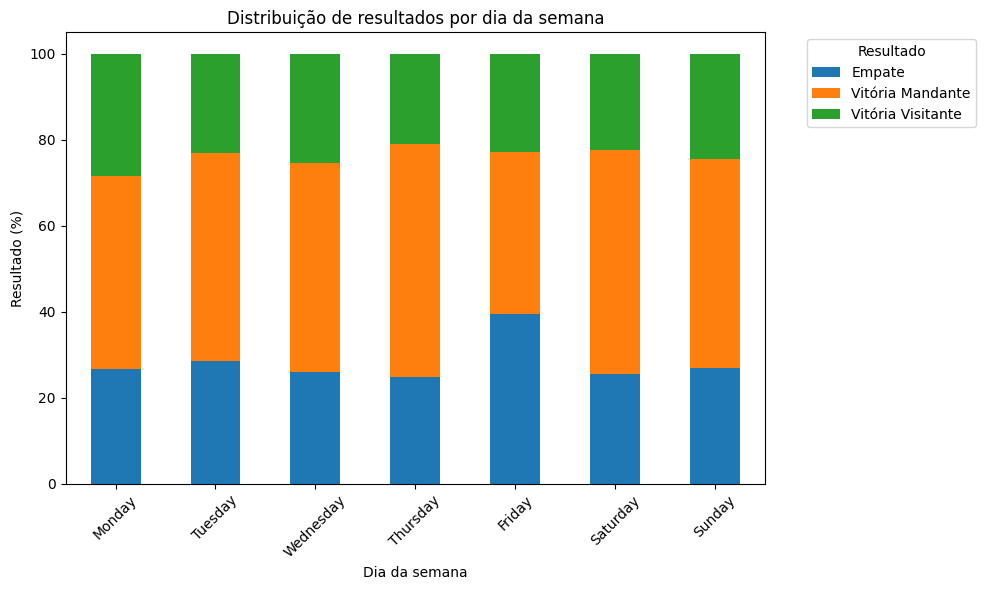

In [224]:
df["data"] = pd.to_datetime(df["data"])
df["dia_semana"] = df["data"].dt.day_name()

def resultado(row):
    if row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    elif row["vencedor"] == row["visitante"]:
        return "Vitória Visitante"
    else:
        return "Empate"

df["resultado"] = df.apply(resultado, axis=1)

distribuicao_dia = (
    df.groupby("dia_semana")["resultado"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

ordem = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
distribuicao_dia = distribuicao_dia.reindex(ordem)

distribuicao_dia.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Distribuição de resultados por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Resultado (%)")
plt.xticks(rotation=45)
plt.legend(title="Resultado")
plt.legend(title="Resultado", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Observa-se padrões uniformes entre os dias da semana (aproximadamente 25-30% de empate). O único dia que foge do padrão é sexta-feira, porém isso se deve à baixa quantidade de jogos nesse dia (48 partidas, contra centenas ou milhares nos demais dias), tornando a porcentagem estatisticamente pouco confiável.

In [225]:
print(df["dia_semana"].value_counts().reindex(ordem))

dia_semana
Monday        232
Tuesday       130
Wednesday    1653
Thursday      725
Friday         48
Saturday     2239
Sunday       4138
Name: count, dtype: int64


Verificando, agora, se o resultado muda conforme o campeonato avança (início x meio x fim de temporada), o que pode indicar efeito de cansaço ou de decisões em jogo.

Número de jogos por mês:

In [226]:
df["mes"] = df["data"].dt.month
print(df["mes"].value_counts().sort_index())

mes
1       59
2       53
3       22
4      352
5      870
6      934
7     1278
8     1383
9     1258
10    1371
11    1216
12     369
Name: count, dtype: int64


Os três primeiros meses do ano (janeiro, fevereiro e março) têm volume de jogos muito baixo comparado aos demais, já que o Brasileirão normalmente não está em andamento nesse período. Por isso, eliminamos esses meses da análise e dividimos o restante da temporada (abril a dezembro) em três fases:

resultado          Empate  Vitória Mandante  Vitória Visitante
fase_temporada                                                
Início          27.504638         49.350649          23.144712
Meio            26.715999         49.374841          23.909161
Fim             24.966171         50.372124          24.661705


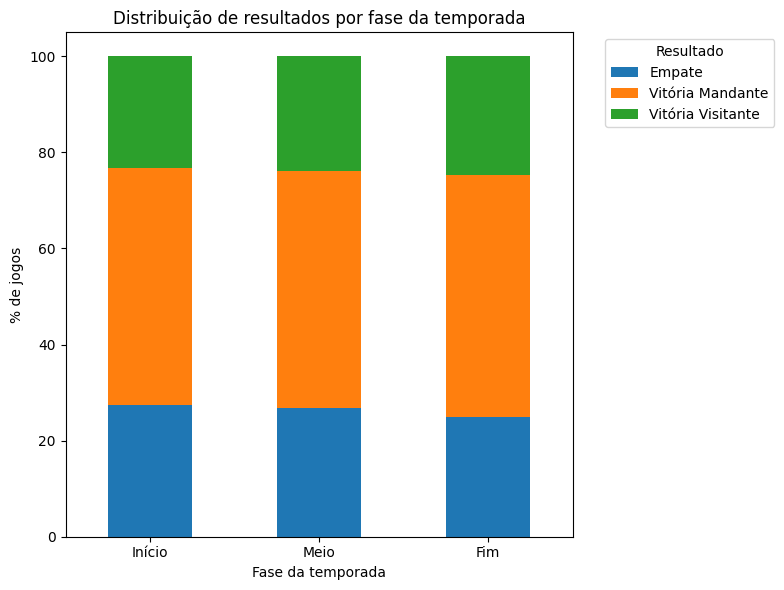

In [227]:
def fase_temporada(mes):
    if mes in [4, 5, 6]:
        return "Início"
    elif mes in [7, 8, 9]:
        return "Meio"
    elif mes in [10, 11, 12]:
        return "Fim"
    else:
        return None  # jan/fev/mar excluídos (baixo volume, fora da temporada regular)

df["fase_temporada"] = df["mes"].apply(fase_temporada)

distribuicao_fase = (
    df.dropna(subset=["fase_temporada"])
    .groupby("fase_temporada")["resultado"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
    .reindex(["Início", "Meio", "Fim"])
)

print(distribuicao_fase)

distribuicao_fase.plot(kind="bar", stacked=True, figsize=(8, 6))
plt.title("Distribuição de resultados por fase da temporada")
plt.xlabel("Fase da temporada")
plt.ylabel("% de jogos")
plt.xticks(rotation=0)
plt.legend(title="Resultado", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Constatação:** A distribuição de resultados é praticamente estável entre início, meio e fim da temporada (empate variando de ~25% a 27,5%, mandante entre ~49% e 50,4%, visitante entre ~23% e 24,7%). Não há indício de efeito de cansaço acumulado ou de maior peso decisivo nos jogos conforme o campeonato avança, ou seja, a fase da temporada não parece influenciar o resultado das partidas.

### 3.8 Relações de técnicos

Verificando quais técnicos têm mais jogos registrados no dataset

L. Venker de Menezes    285.0
V. Carmo Mancini        257.0
Renato Gaúcho           256.0
R. Ceni                 231.0
A. Stival               212.0
D. Silvestre Júnior     203.0
J. Ribeiro Ventura      200.0
A. Ferreira             196.0
R. Machado Marques      189.0
J. Vojvoda              187.0
Name: count, dtype: float64


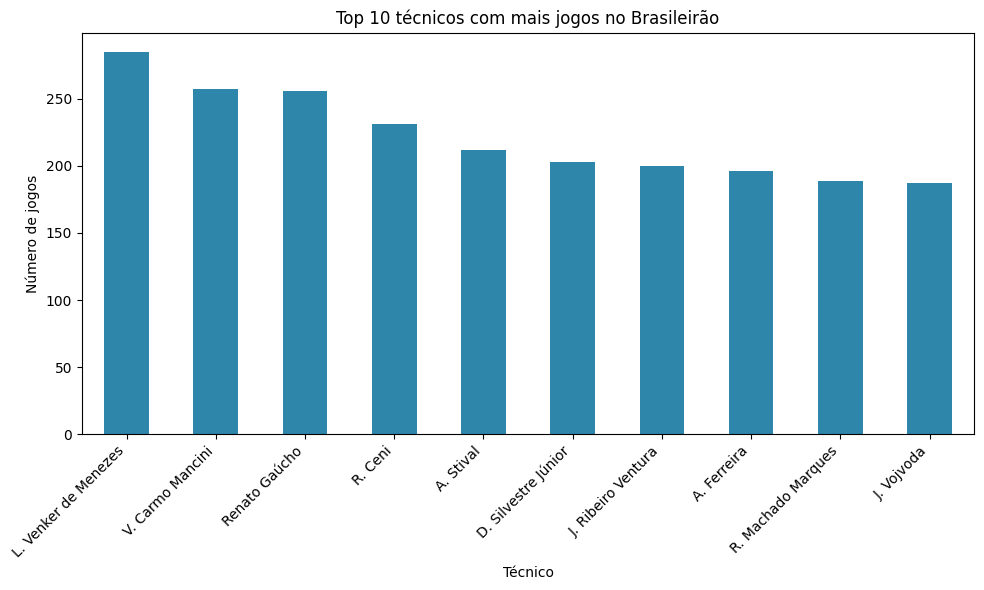

In [228]:
total_jogos = df["tecnico_mandante"].value_counts().add(df["tecnico_visitante"].value_counts(), fill_value=0)
total_jogos = total_jogos.sort_values(ascending=False)

print(total_jogos.head(10))

plt.figure(figsize=(10, 6))
total_jogos.head(10).plot(kind="bar", color="#2E86AB")
plt.title("Top 10 técnicos com mais jogos no Brasileirão")
plt.xlabel("Técnico")
plt.ylabel("Número de jogos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Verificando os técnicos com maior taxa de vitória, considerando apenas técnicos com pelo menos 50 jogos, pra evitar ruído de amostra pequena:

tecnico
A. Bacchi              58.024691
A. Moreira Ferreira    53.289474
J. Sampaoli Moya       52.127660
L. Scolari             50.354610
A. Stival              50.000000
D. Silvestre Júnior    46.305419
L. Culpi               46.099291
Renato Gaúcho          46.093750
O. Hellmann            45.454545
E. Coudet              44.615385
Name: vitoria, dtype: float64
tecnico
E. Baptista                 30.864198
J. de Amorim Campos         29.523810
A. Cardoso de Oliveira      29.411765
L. Cirne Lima de Lorenzi    28.000000
V. Eutrópio                 27.450980
G. Kleina                   27.102804
M. dos Santos Gonçalves     26.890756
N. da Silveira Júnior       26.732673
E. de Souza Barroca         26.136364
D. Ghidoni Junior           23.214286
Name: vitoria, dtype: float64


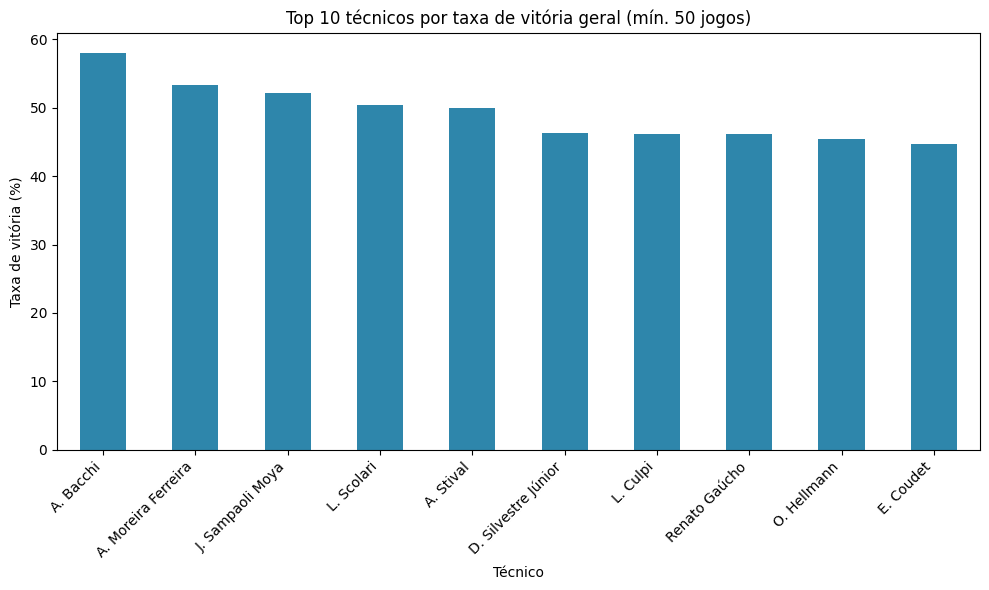

In [229]:
lado_mandante = pd.DataFrame({
    "tecnico": df["tecnico_mandante"],
    "vitoria": df["resultado"] == "Vitória Mandante"
})
lado_visitante = pd.DataFrame({
    "tecnico": df["tecnico_visitante"],
    "vitoria": df["resultado"] == "Vitória Visitante"
})
tecnicos = pd.concat([lado_mandante, lado_visitante])

contagem_tecnico = tecnicos["tecnico"].value_counts()
tecnicos_validos = contagem_tecnico[contagem_tecnico >= 50].index
tecnicos_top = tecnicos[tecnicos["tecnico"].isin(tecnicos_validos)]

taxa_vitoria_tecnico = (
    tecnicos_top.groupby("tecnico")["vitoria"]
    .mean().mul(100).sort_values(ascending=False)
)

print(taxa_vitoria_tecnico.head(10))
print(taxa_vitoria_tecnico.tail(10))

plt.figure(figsize=(10, 6))
taxa_vitoria_tecnico.head(10).plot(kind="bar", color="#2E86AB")
plt.title("Top 10 técnicos por taxa de vitória geral (mín. 50 jogos)")
plt.xlabel("Técnico")
plt.ylabel("Taxa de vitória (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Verificando se algum técnico se destaca por um estilo mais "conservador", com taxa de empate acima da média (~26%), considerando volume mínimo de jogos:

tecnico
D. Aguirre Camblor          32.954545
M. Nogueira Barbieri        31.617647
H. Crespo                   31.578947
J. Mannarino                31.496063
V. Luxemburgo da Silva      31.410256
P. Faria Caixinha           30.882353
T. Retzalff Nunes           30.526316
J. de Amorim Campos         30.476190
F. Carille                  30.392157
L. Cirne Lima de Lorenzi    30.000000
dtype: float64


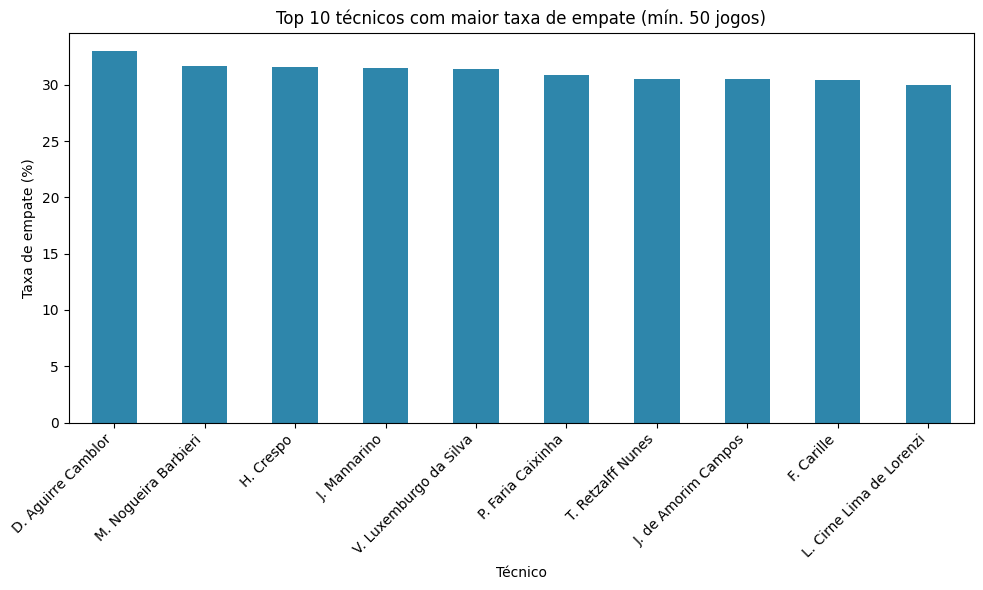

In [230]:
empates_lista = []
tecnicos_lista = []

for i in range(len(df)):
    linha = df.iloc[i]

    tecnicos_lista.append(linha["tecnico_mandante"])
    if linha["resultado"] == "Empate":
        empates_lista.append(1)
    else:
        empates_lista.append(0)

    tecnicos_lista.append(linha["tecnico_visitante"])
    if linha["resultado"] == "Empate":
        empates_lista.append(1)
    else:
        empates_lista.append(0)

df_empates = pd.DataFrame({
    "tecnico": tecnicos_lista,
    "empate": empates_lista
})

total_jogos_tecnico = df_empates["tecnico"].value_counts()
total_empates_tecnico = df_empates.groupby("tecnico")["empate"].sum()

taxa_empate_tecnico = (total_empates_tecnico / total_jogos_tecnico) * 100
taxa_empate_tecnico = taxa_empate_tecnico[total_jogos_tecnico >= 50]
taxa_empate_tecnico = taxa_empate_tecnico.sort_values(ascending=False)

print(taxa_empate_tecnico.head(10))

plt.figure(figsize=(10, 6))
taxa_empate_tecnico.head(10).plot(kind="bar", color="#2E86AB")
plt.title("Top 10 técnicos com maior taxa de empate (mín. 50 jogos)")
plt.xlabel("Técnico")
plt.ylabel("Taxa de empate (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.9 Relações de placares

Verificando quais placares exatos mais se repetem no campeonato:

placar
1x0    1210
1x1    1133
2x1     899
2x0     774
0x0     724
0x1     654
1x2     562
2x2     475
3x0     412
3x1     398
Name: count, dtype: int64


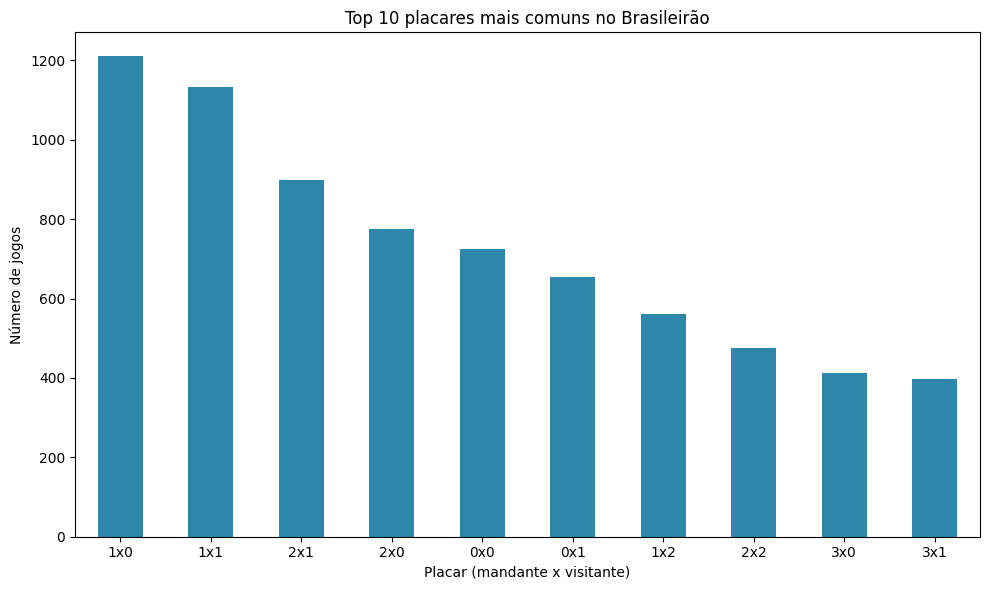

In [231]:
df["placar"] = df["mandante_Placar"].astype(str) + "x" + df["visitante_Placar"].astype(str)

placares_comuns = df["placar"].value_counts().head(10)

print(placares_comuns)

plt.figure(figsize=(10, 6))
placares_comuns.plot(kind="bar", color="#2E86AB")
plt.title("Top 10 placares mais comuns no Brasileirão")
plt.xlabel("Placar (mandante x visitante)")
plt.ylabel("Número de jogos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Verificando quantos jogos têm 0, 1, 2, 3... gols no total (mandante + visitante):

total_gols
0      724
1     1864
2     2249
3     2007
4     1228
5      631
6      282
7      127
8       40
9        8
10       4
11       1
Name: count, dtype: int64


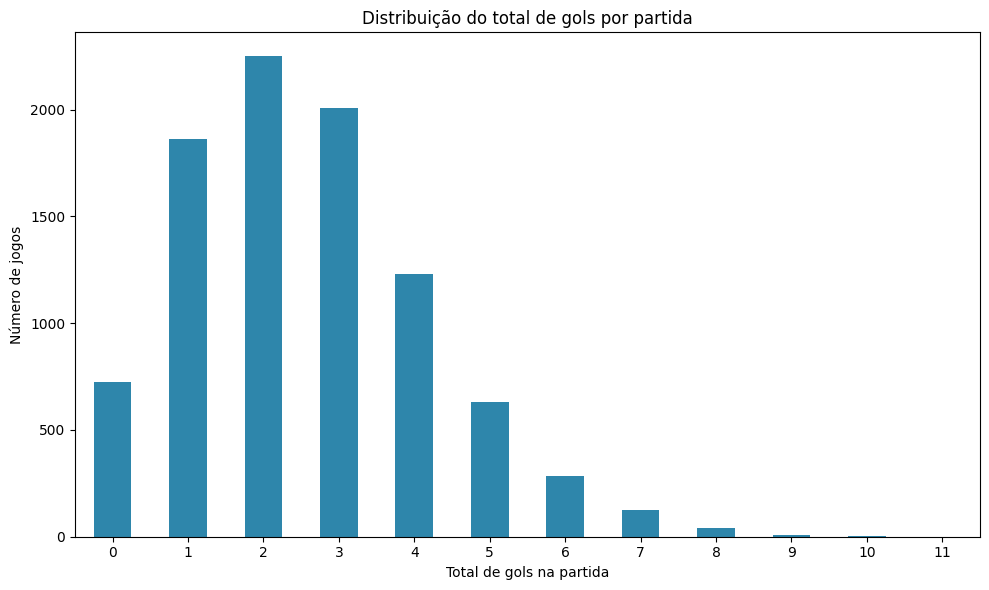

In [232]:
df["total_gols"] = df["mandante_Placar"] + df["visitante_Placar"]

distribuicao_gols = df["total_gols"].value_counts().sort_index()

print(distribuicao_gols)

plt.figure(figsize=(10, 6))
distribuicao_gols.plot(kind="bar", color="#2E86AB")
plt.title("Distribuição do total de gols por partida")
plt.xlabel("Total de gols na partida")
plt.ylabel("Número de jogos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Definindo goleada como diferença de 3 ou mais gols, verificando a frequência e se o mandante goleia mais que o visitante:

goleada
Não                     8027
Goleada do mandante      882
Goleada do visitante     256
Name: count, dtype: int64


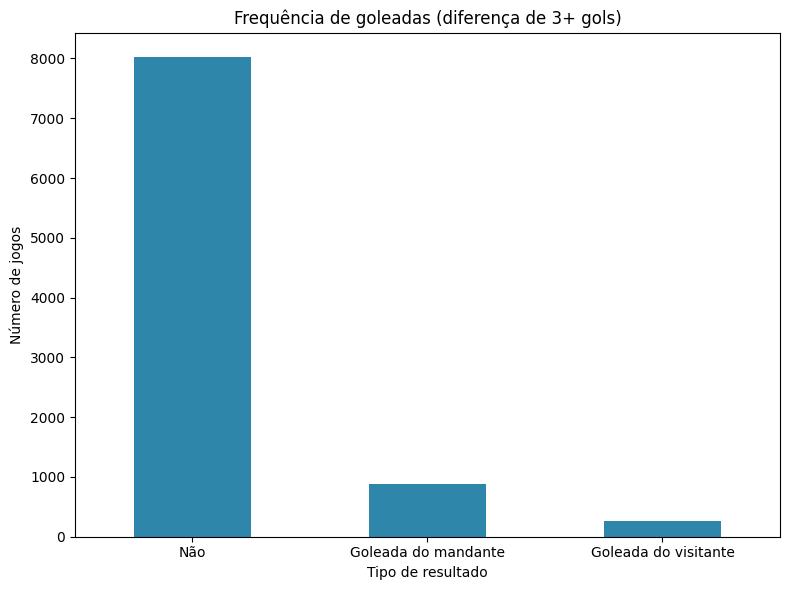

In [233]:
df["diferenca_gols"] = df["mandante_Placar"] - df["visitante_Placar"]

df["goleada"] = "Não"
df.loc[df["diferenca_gols"] >= 3, "goleada"] = "Goleada do mandante"
df.loc[df["diferenca_gols"] <= -3, "goleada"] = "Goleada do visitante"

contagem_goleadas = df["goleada"].value_counts()

print(contagem_goleadas)

plt.figure(figsize=(8, 6))
contagem_goleadas.plot(kind="bar", color="#2E86AB")
plt.title("Frequência de goleadas (diferença de 3+ gols)")
plt.xlabel("Tipo de resultado")
plt.ylabel("Número de jogos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Verificando se o jogo "travado" (0x0) está ficando mais ou menos comum ao longo das temporadas:

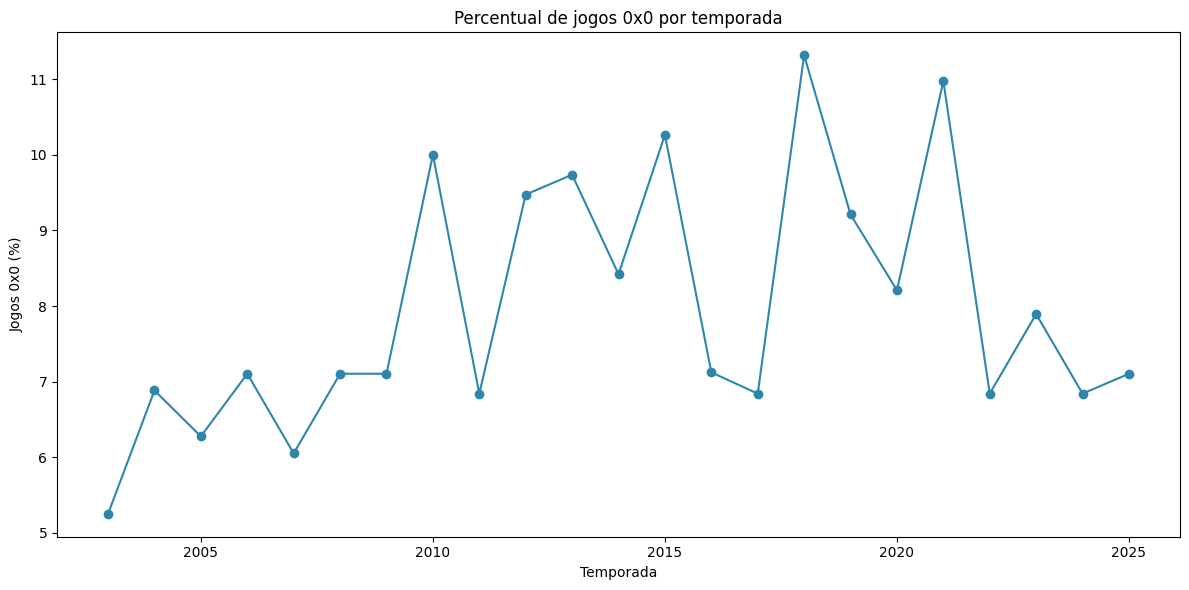

In [234]:
df["zero_a_zero"] = (df["mandante_Placar"] == 0) & (df["visitante_Placar"] == 0)

zero_a_zero_por_temporada = df.groupby("temporada")["zero_a_zero"].mean() * 100

plt.figure(figsize=(12, 6))
plt.plot(zero_a_zero_por_temporada.index, zero_a_zero_por_temporada.values, marker='o', color='#2E86AB')
plt.title("Percentual de jogos 0x0 por temporada")
plt.xlabel("Temporada")
plt.ylabel("Jogos 0x0 (%)")
plt.tight_layout()
plt.show()

Comparando a média de gols marcados pelo mandante e pelo visitante:

Média de gols do mandante: 1.54
Média de gols do visitante: 1.03


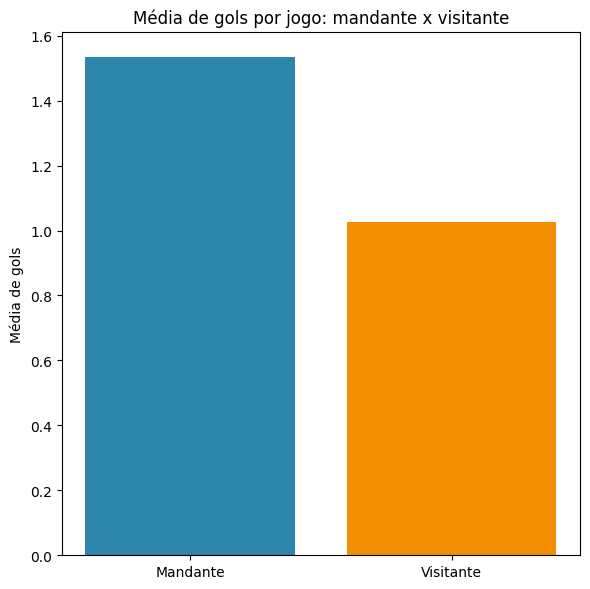

In [235]:
media_gols_mandante = df["mandante_Placar"].mean()
media_gols_visitante = df["visitante_Placar"].mean()

print(f"Média de gols do mandante: {media_gols_mandante:.2f}")
print(f"Média de gols do visitante: {media_gols_visitante:.2f}")

plt.figure(figsize=(6, 6))
plt.bar(["Mandante", "Visitante"], [media_gols_mandante, media_gols_visitante], color=['#2E86AB', '#F18F01'])
plt.title("Média de gols por jogo: mandante x visitante")
plt.ylabel("Média de gols")
plt.tight_layout()
plt.show()

Verificando qual o placar mais típico dentro de cada categoria de resultado (vitória do mandante, do visitante, ou empate):

In [236]:
for tipo_resultado in ["Vitória Mandante", "Vitória Visitante", "Empate"]:
    jogos_do_tipo = df[df["resultado"] == tipo_resultado]
    placar_mais_comum = jogos_do_tipo["placar"].value_counts().head(3)
    print(f"--- {tipo_resultado} ---")
    print(placar_mais_comum)
    print()

--- Vitória Mandante ---
placar
1x0    1210
2x1     899
2x0     774
Name: count, dtype: int64

--- Vitória Visitante ---
placar
0x1    654
1x2    562
0x2    342
Name: count, dtype: int64

--- Empate ---
placar
1x1    1133
0x0     724
2x2     475
Name: count, dtype: int64



**Constatação:** O padrão de placares confirma o fator casa já observado nas seções anteriores: o mandante marca em média 1,53 gols por jogo contra 1,03 do visitante, e goleia mais que o dobro de vezes (882 vs 256). O placar mais comum do campeonato é 1x0 (1.210 jogos), seguido por 1x1 (1.133) e 2x1 (899) (resultados de margem apertada dominam), coerente com o total de gols por partida também concentrado em valores baixos (2 e 3 gols somam quase metade dos jogos). Jogos 0x0 representam entre 5% e 11% das partidas por temporada, sem tendência clara de queda ou alta ao longo dos anos, apenas oscilação natural. No geral, os dados de placar reforçam que o Brasileirão é um campeonato de resultados apertados, com vantagem consistente (mas não avassaladora) para quem joga em casa.

# 4. Modelagem preditiva

Nesta seção, construímos um modelo de **classificação** para prever o **resultado da partida** (Vitória do Mandante / Empate / Vitória do Visitante).

**Cuidado central em todo o notebook:** todas as features de histórico (forma recente e H2H) usam **apenas jogos anteriores à partida sendo prevista** (nunca informação do jogo atual ou do futuro). Isso evita vazamento de dados (*data leakage*).

**O que tem nesta seção:**
- 4.1 – 4.5: preparação de dados e engenharia de atributos (forma recente + confronto direto)
- 4.6: análise de outliers (boxplot)
- 4.7: preparação para modelagem (split temporal)
- 4.8: modelo de classificação (baseline)
- 4.9: matriz de confusão
- 4.10: curva ROC-AUC (multiclasse)
- 4.11: hyperparameter tuning
- 4.12: conclusões

## 4.1 Importações

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
)

## 4.2 Carregamento e limpeza inicial

In [238]:
df = pd.read_csv('https://raw.githubusercontent.com/RikelmeSousadeCarvalho/ModelagemPreditivaBrasileirao/refs/heads/main/campeonato-brasileiro-full.csv')

df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
df = df.sort_values("data").reset_index(drop=True)
df["temporada"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia_semana"] = df["data"].dt.day_name()

# a coluna "interestadual" original comparava mandante_Estado == visitante_Estado,
# o que na verdade identifica jogos do MESMO estado (não interestaduais).
df["mesmo_estado"] = (df["mandante_Estado"] == df["visitante_Estado"]).astype(int)

def fase_temporada(mes):
    if mes in [4, 5, 6]:
        return "Inicio"
    elif mes in [7, 8, 9]:
        return "Meio"
    elif mes in [10, 11, 12]:
        return "Fim"
    return "Fora_de_temporada"

df["fase_temporada"] = df["mes"].apply(fase_temporada)
df["total_gols"] = df["mandante_Placar"] + df["visitante_Placar"]

df.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,temporada,mes,dia_semana,mesmo_estado,fase_temporada,total_gols
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,...,2,SP,RJ,NaN,2003,3,Saturday,0,Fora_de_temporada,6
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,...,0,PR,RS,NaN,2003,3,Saturday,0,Fora_de_temporada,2
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,...,1,RJ,PR,NaN,2003,3,Sunday,0,Fora_de_temporada,2
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,...,2,GO,PA,NaN,2003,3,Sunday,0,Fora_de_temporada,4
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,...,1,RS,SP,NaN,2003,3,Sunday,0,Fora_de_temporada,2


## 4.3 Alvo de classificação: resultado completo

Usamos o resultado completo da partida (3 classes), que tem distribuição mais equilibrada do que alvos como "goleada".

In [239]:
def resultado(row):
    if row["vencedor"] == row["mandante"]:
        return "Vitoria_Mandante"
    elif row["vencedor"] == "-":
        return "Empate"
    return "Vitoria_Visitante"

df["resultado"] = df.apply(resultado, axis=1)

print("Distribuição do alvo 'resultado':")
print(df["resultado"].value_counts(normalize=True).mul(100).round(1))

Distribuição do alvo 'resultado':
resultado
Vitoria_Mandante     49.6
Empate               26.4
Vitoria_Visitante    23.9
Name: proportion, dtype: float64


## 4.4 Features de forma recente (últimos 5 jogos, sem vazamento)

Para cada time, calculamos médias móveis de gols marcados/sofridos e taxa de vitória/goleada usando **apenas jogos anteriores** (via `shift(1)` antes do `rolling`).

In [240]:
mandante_view = df[["ID", "data", "mandante", "mandante_Placar", "visitante_Placar"]].copy()
mandante_view.columns = ["ID", "data", "time", "gols_pro", "gols_contra"]
mandante_view["mandante_flag"] = 1

visitante_view = df[["ID", "data", "visitante", "visitante_Placar", "mandante_Placar"]].copy()
visitante_view.columns = ["ID", "data", "time", "gols_pro", "gols_contra"]
visitante_view["mandante_flag"] = 0

historico = pd.concat([mandante_view, visitante_view], ignore_index=True)
historico = historico.sort_values(["time", "data"]).reset_index(drop=True)

historico["vitoria"] = (historico["gols_pro"] > historico["gols_contra"]).astype(int)
historico["goleada_propria"] = ((historico["gols_pro"] - historico["gols_contra"]).abs() >= 3).astype(int)

JANELA = 5
grupo = historico.groupby("time")

historico["media_gols_pro_L5"] = grupo["gols_pro"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["media_gols_contra_L5"] = grupo["gols_contra"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["taxa_vitoria_L5"] = grupo["vitoria"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["taxa_goleada_L5"] = grupo["goleada_propria"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)

cols_hist = ["ID", "time", "media_gols_pro_L5", "media_gols_contra_L5", "taxa_vitoria_L5", "taxa_goleada_L5"]

hist_mandante = historico[historico["mandante_flag"] == 1][cols_hist].copy()
hist_mandante.columns = ["ID", "mandante", "mandante_media_gols_pro_L5", "mandante_media_gols_contra_L5",
                          "mandante_taxa_vitoria_L5", "mandante_taxa_goleada_L5"]

hist_visitante = historico[historico["mandante_flag"] == 0][cols_hist].copy()
hist_visitante.columns = ["ID", "visitante", "visitante_media_gols_pro_L5", "visitante_media_gols_contra_L5",
                           "visitante_taxa_vitoria_L5", "visitante_taxa_goleada_L5"]

df = df.merge(hist_mandante, on=["ID", "mandante"], how="left")
df = df.merge(hist_visitante, on=["ID", "visitante"], how="left")

features_l5 = [
    "mandante_media_gols_pro_L5", "mandante_media_gols_contra_L5", "mandante_taxa_vitoria_L5", "mandante_taxa_goleada_L5",
    "visitante_media_gols_pro_L5", "visitante_media_gols_contra_L5", "visitante_taxa_vitoria_L5", "visitante_taxa_goleada_L5",
]
# times na estreia do campeonato não têm histórico ainda -> preenchemos com a média geral
for col in features_l5:
    df[col] = df[col].fillna(df[col].mean())

df[["mandante", "visitante"] + features_l5].tail()

,mandante,visitante,mandante_media_gols_pro_L5,mandante_media_gols_contra_L5,mandante_taxa_vitoria_L5,mandante_taxa_goleada_L5,visitante_media_gols_pro_L5,visitante_media_gols_contra_L5,visitante_taxa_vitoria_L5,visitante_taxa_goleada_L5
9160,Ceara,Palmeiras,0.6,1.4,0.2,0.2,1.0,0.8,0.2,0.2
9161,Fluminense,Bahia,2.0,0.4,0.6,0.2,1.6,1.2,0.4,0.0
9162,Vitoria,Sao Paulo,1.0,1.0,0.4,0.2,1.2,2.2,0.4,0.4
9163,Corinthians,Juventude,1.2,1.8,0.2,0.2,1.6,2.0,0.2,0.2
9164,Internacional,Bragantino,1.2,2.4,0.2,0.4,1.4,0.8,0.6,0.4


## 4.5 Features de confronto direto — H2H

Para cada partida, olhamos o histórico de jogos **anteriores** entre os dois mesmos times (independente de mando de campo):
- `h2h_jogos_anteriores`: quantos confrontos diretos já aconteceram entre esses dois times antes dessa partida
- `h2h_taxa_vitoria_mandante`: em quantos desses confrontos anteriores o time que hoje é mandante saiu vencedor
- `h2h_media_gols`: média de gols totais nos confrontos anteriores entre esses dois times

In [241]:
df["confronto_id"] = df.apply(lambda r: "_".join(sorted([r["mandante"], r["visitante"]])), axis=1)

registros_h2h = []
for confronto_id, grupo_confronto in df.sort_values("data").groupby("confronto_id"):
    grupo_confronto = grupo_confronto.sort_values("data")
    vencedores_anteriores, gols_anteriores = [], []

    for _, row in grupo_confronto.iterrows():
        n = len(vencedores_anteriores)
        if n == 0:
            taxa_vit_h2h, media_gols_h2h = np.nan, np.nan
        else:
            vit_atual = sum(1 for v in vencedores_anteriores if v == row["mandante"])
            taxa_vit_h2h = vit_atual / n
            media_gols_h2h = np.mean(gols_anteriores)

        registros_h2h.append({
            "ID": row["ID"],
            "h2h_jogos_anteriores": n,
            "h2h_taxa_vitoria_mandante": taxa_vit_h2h,
            "h2h_media_gols": media_gols_h2h,
        })

        # só adiciona o jogo atual ao histórico DEPOIS de registrar a feature
        vencedores_anteriores.append(row["vencedor"])
        gols_anteriores.append(row["total_gols"])

h2h_df = pd.DataFrame(registros_h2h)
df = df.merge(h2h_df, on="ID", how="left")

# primeiro encontro histórico entre dois times -> sem histórico, preenchido com médias gerais
df["h2h_taxa_vitoria_mandante"] = df["h2h_taxa_vitoria_mandante"].fillna(df["h2h_taxa_vitoria_mandante"].mean())
df["h2h_media_gols"] = df["h2h_media_gols"].fillna(df["h2h_media_gols"].mean())

print(f"Total de confrontos (pares de times) únicos no dataset: {df['confronto_id'].nunique()}")
df[["mandante", "visitante", "h2h_jogos_anteriores", "h2h_taxa_vitoria_mandante", "h2h_media_gols"]].tail()

Total de confrontos (pares de times) únicos no dataset: 773


,mandante,visitante,h2h_jogos_anteriores,h2h_taxa_vitoria_mandante,h2h_media_gols
9160,Ceara,Palmeiras,15,0.266667,2.400000
9161,Fluminense,Bahia,25,0.480000,2.280000
9162,Vitoria,Sao Paulo,23,0.130435,3.043478
9163,Corinthians,Juventude,17,0.235294,2.823529
9164,Internacional,Bragantino,11,0.545455,2.181818


## 4.6 Análise de outliers (boxplot)

Antes de treinar o modelo, olhamos a distribuição das variáveis numéricas mais relevantes pra identificar outliers, ou seja, jogos com números fora do padrão que podem distorcer médias e treinamento.

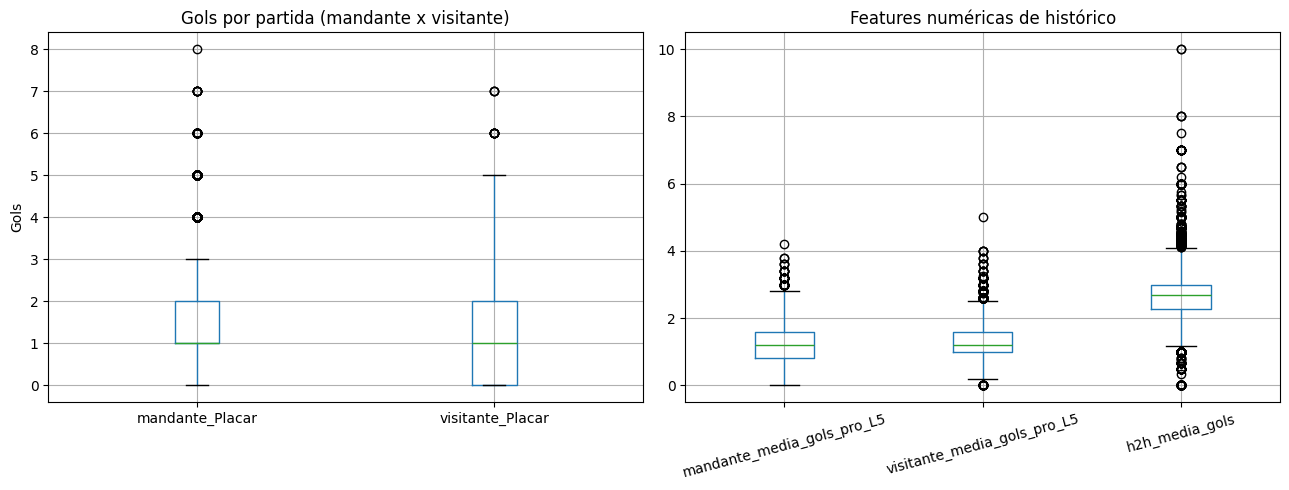

Outliers pela regra do IQR (1.5x acima do 3º quartil):
  mandante_Placar: limite = 3.5 gols | outliers = 632 (6.9% dos jogos)
  visitante_Placar: limite = 5.0 gols | outliers = 11 (0.1% dos jogos)


In [242]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df[["mandante_Placar", "visitante_Placar"]].boxplot(ax=axes[0])
axes[0].set_title("Gols por partida (mandante x visitante)")
axes[0].set_ylabel("Gols")

features_para_boxplot = ["mandante_media_gols_pro_L5", "visitante_media_gols_pro_L5", "h2h_media_gols"]
df[features_para_boxplot].boxplot(ax=axes[1])
axes[1].set_title("Features numéricas de histórico")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# quantificando outliers pela regra do IQR (intervalo interquartil)
print("Outliers pela regra do IQR (1.5x acima do 3º quartil):")
for col in ["mandante_Placar", "visitante_Placar"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    n_outliers = (df[col] > limite_superior).sum()
    print(f"  {col}: limite = {limite_superior:.1f} gols | outliers = {n_outliers} ({n_outliers/len(df)*100:.1f}% dos jogos)")

**Observação:** os outliers em `mandante_Placar` (jogos com 4+ gols do mandante, ~6-7% dos jogos) são **goleadas reais**, não erros de digitação. Decidimos mantê-los no dataset, pois representam eventos legítimos do futebol e removê-los enviesaria as médias de forma recente. A alta dispersão em `h2h_media_gols` é esperada: confrontos entre times que se enfrentaram poucas vezes têm médias mais sensíveis a valores extremos (pouca amostra).

## 4.7 Preparação para modelagem

**Split temporal** (não aleatório!): treinamos com os jogos mais antigos e testamos nos mais recentes, simulando o uso real do modelo (prever jogos futuros a partir do histórico).

In [243]:
features_numericas = [
    "rodata", "mesmo_estado",
    "mandante_media_gols_pro_L5", "mandante_media_gols_contra_L5",
    "mandante_taxa_vitoria_L5", "mandante_taxa_goleada_L5",
    "visitante_media_gols_pro_L5", "visitante_media_gols_contra_L5",
    "visitante_taxa_vitoria_L5", "visitante_taxa_goleada_L5",
    "h2h_jogos_anteriores", "h2h_taxa_vitoria_mandante", "h2h_media_gols",
]
features_categoricas = ["dia_semana", "fase_temporada"]
todas_features = features_numericas + features_categoricas

corte = int(len(df) * 0.85)
treino, teste = df.iloc[:corte], df.iloc[corte:]
X_treino, X_teste = treino[todas_features], teste[todas_features]
y_treino, y_teste = treino["resultado"], teste["resultado"]

print(f"Treino: {len(treino)} jogos (até {treino['data'].max().date()})")
print(f"Teste:  {len(teste)} jogos (de {teste['data'].min().date()} até {teste['data'].max().date()})")

preprocessador = ColumnTransformer([
    ("num", StandardScaler(), features_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
])

Treino: 7790 jogos (até 2022-07-02)
Teste:  1375 jogos (de 2022-07-03 até 2025-12-07)


## 4.8 Modelo de classificação (baseline)

In [244]:
modelos_clf = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
}

resultados_modelos = {}
for nome, modelo in modelos_clf.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    pred = pipe.predict(X_teste)
    resultados_modelos[nome] = pipe

    print(f"--- {nome} ---")
    print(f"Acurácia: {accuracy_score(y_teste, pred):.3f}")
    print(f"F1 macro: {f1_score(y_teste, pred, average='macro'):.3f}")
    print(classification_report(y_teste, pred))
    print()

baseline_acc = (y_teste == "Vitoria_Mandante").mean()
print(f"[Baseline ingênuo] Acurácia chutando sempre 'Vitória Mandante': {baseline_acc:.3f}")

# usamos o Random Forest como modelo principal para as próximas seções
melhor_pipe = resultados_modelos["Random Forest"]

--- Regressão Logística ---
Acurácia: 0.420
F1 macro: 0.379
                   precision    recall  f1-score   support

           Empate       0.30      0.15      0.20       358
 Vitoria_Mandante       0.56      0.49      0.52       658
Vitoria_Visitante       0.33      0.55      0.41       359

         accuracy                           0.42      1375
        macro avg       0.39      0.40      0.38      1375
     weighted avg       0.43      0.42      0.41      1375


--- Random Forest ---
Acurácia: 0.473
F1 macro: 0.282
                   precision    recall  f1-score   support

           Empate       0.34      0.06      0.10       358
 Vitoria_Mandante       0.49      0.92      0.64       658
Vitoria_Visitante       0.33      0.06      0.11       359

         accuracy                           0.47      1375
        macro avg       0.39      0.35      0.28      1375
     weighted avg       0.41      0.47      0.36      1375


[Baseline ingênuo] Acurácia chutando sempre 'Vitória

## 4.9 Matriz de confusão

Mostra, pra cada classe real, quantas vezes o modelo acertou e pra qual classe errada ele "confundiu" a previsão.

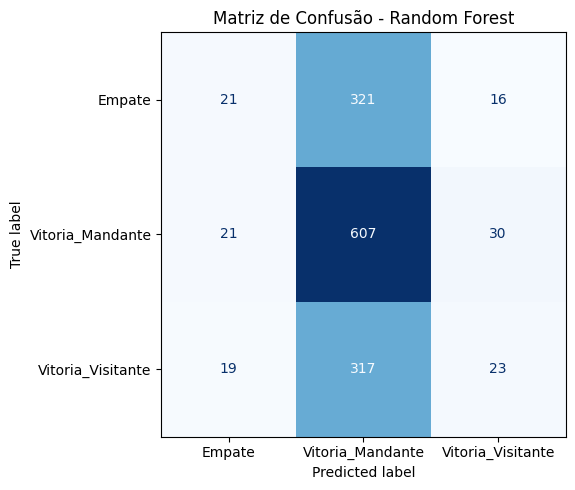

In [245]:
pred = melhor_pipe.predict(X_teste)
cm = confusion_matrix(y_teste, pred, labels=melhor_pipe.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=melhor_pipe.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.show()

A linha é a classe real e a coluna é a classe que o modelo previu. Repare que o modelo tende a prever "Vitória Mandante" com muita frequência mesmo quando o resultado real foi outro. Isso é um reflexo do desbalanceamento residual das classes e da dificuldade real do problema.

## 4.10 Curva ROC-AUC (multiclasse)

Como o problema tem 3 classes, usamos a estratégia **one-vs-rest**: para cada classe, tratamos como "essa classe" vs "todas as outras" e plotamos uma curva ROC separada.

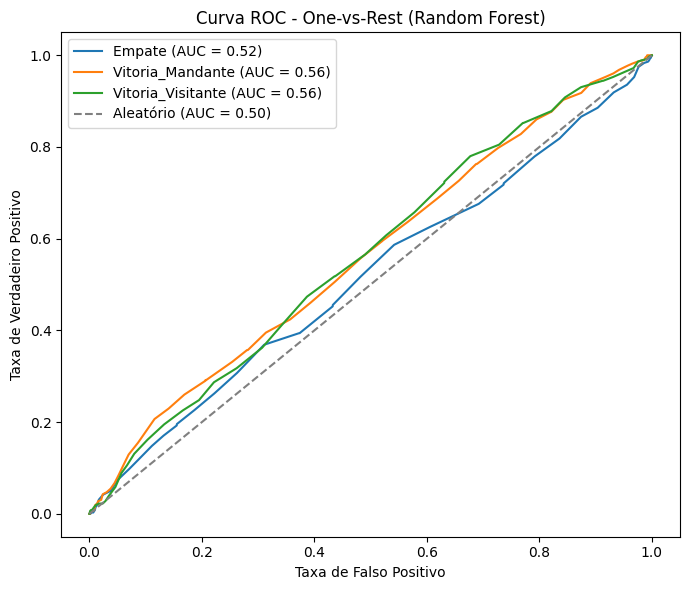

AUC macro (média das 3 classes): 0.547


In [246]:
proba = melhor_pipe.predict_proba(X_teste)
classes = melhor_pipe.classes_
y_teste_bin = label_binarize(y_teste, classes=classes)

fig, ax = plt.subplots(figsize=(7, 6))
for i, classe in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_teste_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{classe} (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.50)")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC - One-vs-Rest (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()

auc_macro = roc_auc_score(y_teste, proba, multi_class="ovr", average="macro")
print(f"AUC macro (média das 3 classes): {auc_macro:.3f}")

Quanto mais a curva se afasta da linha diagonal cinza (que representa um classificador aleatório, AUC = 0,50) em direção ao canto superior esquerdo, melhor o modelo. Aqui, as três curvas ficam bem próximas da diagonal, confirmando numericamente o que já víamos na matriz de confusão que o modelo tem pouca capacidade de discriminar entre as classes.

## 4.11 Hyperparameter tuning

Buscamos a melhor combinação de hiperparâmetros do Random Forest via `RandomizedSearchCV`. Como os dados são temporais, usamos `TimeSeriesSplit` (em vez de K-Fold comum) para a validação cruzada e isso garante que, em cada fold, o modelo só é validado em jogos posteriores aos usados no treino daquele fold, mantendo a mesma lógica anti-vazamento do resto do notebook.

In [247]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "modelo__n_estimators": [100, 200, 300, 400],
    "modelo__max_depth": [4, 6, 8, 10, None],
    "modelo__min_samples_leaf": [1, 2, 5, 10],
    "modelo__max_features": ["sqrt", "log2"],
}

pipe_tuning = Pipeline([
    ("prep", preprocessador),
    ("modelo", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

busca = RandomizedSearchCV(
    pipe_tuning, param_dist, n_iter=15, cv=tscv,
    scoring="f1_macro", random_state=42, n_jobs=-1,
)
busca.fit(X_treino, y_treino)

print("Melhores hiperparâmetros encontrados:")
print(busca.best_params_)
print(f"\nMelhor F1 macro médio na validação cruzada: {busca.best_score_:.3f}")

modelo_tunado = busca.best_estimator_
pred_tunado = modelo_tunado.predict(X_teste)

print(f"\n--- Desempenho do modelo tunado no conjunto de teste ---")
print(f"Acurácia: {accuracy_score(y_teste, pred_tunado):.3f}")
print(f"F1 macro: {f1_score(y_teste, pred_tunado, average='macro'):.3f}")
print(classification_report(y_teste, pred_tunado))

Melhores hiperparâmetros encontrados:
{'modelo__n_estimators': 400, 'modelo__min_samples_leaf': 2, 'modelo__max_features': 'log2', 'modelo__max_depth': 6}

Melhor F1 macro médio na validação cruzada: 0.364

--- Desempenho do modelo tunado no conjunto de teste ---
Acurácia: 0.412
F1 macro: 0.375
                   precision    recall  f1-score   support

           Empate       0.28      0.17      0.21       358
 Vitoria_Mandante       0.55      0.49      0.52       658
Vitoria_Visitante       0.32      0.52      0.40       359

         accuracy                           0.41      1375
        macro avg       0.38      0.39      0.37      1375
     weighted avg       0.42      0.41      0.41      1375



**Observação:** o tuning otimiza o F1 macro (métrica mais adequada aqui do que acurácia, já que penaliza igualmente o desempenho em todas as classes, inclusive a minoritária "Empate"). Vale comparar esse resultado com o modelo baseline da seção 4.8, em problemas com sinal preditivo fraco como este, é comum que o ganho do tuning seja pequeno ou mesmo neutro, o que é, por si só, uma informação relevante: sugere que o teto de desempenho está mais limitado pelas **features disponíveis** do que pelos hiperparâmetros do modelo.

## 4.12 Conclusões sobre o modelo

**Resultado (classificação, 3 classes):** mesmo com features de forma recente, confronto direto (H2H) e hyperparameter tuning, a performance do modelo ficou próxima — e por vezes abaixo — do baseline ingênuo de sempre prever "Vitória do Mandante". A matriz de confusão mostra viés claro em favor da classe majoritária, e as curvas ROC (AUC próximo de 0,50-0,55 para todas as classes) confirmam capacidade discriminativa fraca.

**Interpretação:** isso é consistente com a literatura de modelagem esportiva, já que resultados de partidas de futebol têm componente de aleatoriedade muito alto, e estatísticas agregadas de forma recente e confronto direto têm poder preditivo limitado por si só. Estudos acadêmicos com metodologias mais sofisticadas costumam relatar acurácias na faixa de 50-55% para esse problema de 3 classes, pouco acima do baseline.


# 5. Modelo binário para prever vitória ou não do mandante

No tópico 4, o modelo de classificação com 3 classes (Vitória Mandante / Empate / Vitória Visitante) teve dificuldade real em superar o baseline ingênuo. Aqui testamos uma versão **simplificada** do problema: prever apenas se o **mandante vence ou não** (binário).

**Nossa hipótese:** reduzir de 3 classes para 2 pode aumentar a acurácia e outras métricas, já que o modelo não precisa mais distinguir entre "Empate" e "Vitória Visitante", ou seja, as duas passam a contar como "mandante não vence".


## 5.1 Importações

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
)

## 5.2 Modelo de classificação binária (baseline)

In [249]:
# Novo alvo binário: o mandante vence?
df["mandante_vence"] = (df["resultado"] == "Vitoria_Mandante").astype(int)

print("Distribuição do alvo binário 'mandante_vence':")
print(df["mandante_vence"].value_counts(normalize=True).mul(100).round(1))

# Recria o corte temporal e os conjuntos de treino/teste DEPOIS de criar a coluna nova
corte = int(len(df) * 0.85)
treino, teste = df.iloc[:corte], df.iloc[corte:]
X_treino, X_teste = treino[todas_features], teste[todas_features]
y_treino, y_teste = treino["mandante_vence"], teste["mandante_vence"]

Distribuição do alvo binário 'mandante_vence':
mandante_vence
0    50.4
1    49.6
Name: proportion, dtype: float64


In [250]:
modelos_clf = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
}

resultados_modelos = {}
for nome, modelo in modelos_clf.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    pred = pipe.predict(X_teste)
    proba = pipe.predict_proba(X_teste)[:, 1]
    resultados_modelos[nome] = pipe

    print(f"--- {nome} ---")
    print(f"Acurácia: {accuracy_score(y_teste, pred):.3f}")
    print(f"Precisão: {precision_score(y_teste, pred):.3f}")
    print(f"Recall:   {recall_score(y_teste, pred):.3f}")
    print(f"F1:       {f1_score(y_teste, pred):.3f}")
    print(f"ROC-AUC:  {roc_auc_score(y_teste, proba):.3f}")
    print()

baseline_acc = max(y_teste.mean(), 1 - y_teste.mean())
print(f"[Baseline ingênuo] Acurácia chutando sempre a classe majoritária: {baseline_acc:.3f}")

melhor_pipe = resultados_modelos["Regressão Logística"]

--- Regressão Logística ---
Acurácia: 0.556
Precisão: 0.534
Recall:   0.573
F1:       0.553
ROC-AUC:  0.601

--- Random Forest ---
Acurácia: 0.560
Precisão: 0.543
Recall:   0.505
F1:       0.523
ROC-AUC:  0.569

[Baseline ingênuo] Acurácia chutando sempre a classe majoritária: 0.521


**Comparação com o tópico 4:** a acurácia (aprox 55%) já supera o baseline (aprox 52%) de forma mais consistente do que o modelo de 3 classes e confirma a hipótese de que simplificar o problema binário facilita a tarefa para o modelo.

## 5.3 Matriz de confusão

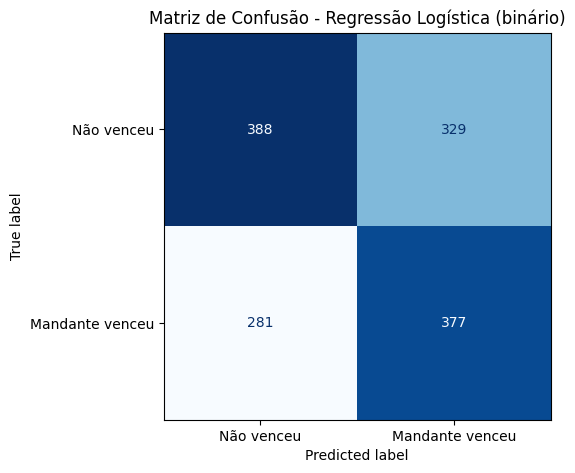

In [251]:
pred = melhor_pipe.predict(X_teste)
cm = confusion_matrix(y_teste, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não venceu", "Mandante venceu"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão - Regressão Logística (binário)")
plt.tight_layout()
plt.show()

## 5.4 Curva ROC-AUC

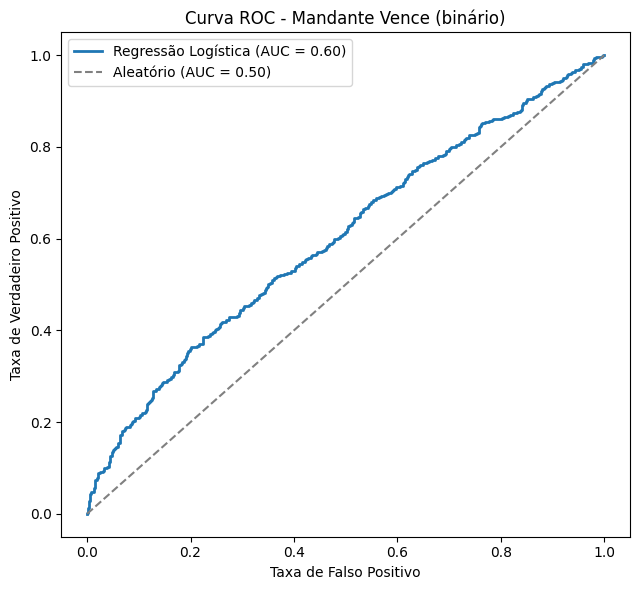

In [252]:
proba = melhor_pipe.predict_proba(X_teste)[:, 1]
fpr, tpr, _ = roc_curve(y_teste, proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color="#1f77b4", linewidth=2, label=f"Regressão Logística (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.50)")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC - Mandante Vence (binário)")
ax.legend()
plt.tight_layout()
plt.show()

**Comparação com o tópico 4:** AUC de ~0,60 aqui contra ~0,53-0,55 no modelo de 3 classes, o que significa uma melhora real, mesmo que um pouco discreta. O modelo binário consegue discriminar melhor entre as duas classes do que o modelo multiclasse conseguia entre as três.

## 5.5 Hyperparameter tuning

Mesma abordagem do tópico 4: `RandomizedSearchCV` com `TimeSeriesSplit` pra manter a validação cruzada respeitando a ordem temporal dos dados.

In [253]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__penalty": ["l2"],
    "modelo__solver": ["lbfgs"],
}

pipe_tuning = Pipeline([
    ("prep", preprocessador),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

busca = RandomizedSearchCV(
    pipe_tuning, param_dist, n_iter=5, cv=tscv,
    scoring="roc_auc", random_state=42, n_jobs=-1,
)
busca.fit(X_treino, y_treino)

print("Melhores hiperparâmetros encontrados:")
print(busca.best_params_)
print(f"\nMelhor ROC-AUC médio na validação cruzada: {busca.best_score_:.3f}")

modelo_tunado = busca.best_estimator_
pred_tunado = modelo_tunado.predict(X_teste)
proba_tunado = modelo_tunado.predict_proba(X_teste)[:, 1]

print(f"\n--- Desempenho do modelo tunado no conjunto de teste ---")
print(f"Acurácia: {accuracy_score(y_teste, pred_tunado):.3f}")
print(f"F1:       {f1_score(y_teste, pred_tunado):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_teste, proba_tunado):.3f}")
print(classification_report(y_teste, pred_tunado, target_names=["Não venceu", "Mandante venceu"]))

Melhores hiperparâmetros encontrados:
{'modelo__solver': 'lbfgs', 'modelo__penalty': 'l2', 'modelo__C': 0.01}

Melhor ROC-AUC médio na validação cruzada: 0.563

--- Desempenho do modelo tunado no conjunto de teste ---
Acurácia: 0.564
F1:       0.552
ROC-AUC:  0.601
                 precision    recall  f1-score   support

     Não venceu       0.58      0.57      0.58       717
Mandante venceu       0.54      0.56      0.55       658

       accuracy                           0.56      1375
      macro avg       0.56      0.56      0.56      1375
   weighted avg       0.56      0.56      0.56      1375



## 5.6 Conclusões: o binário é realmente melhor?

**Sim!** Comparando com o tópico 4 (3 classes):

| Métrica | Multiclasse (tópico 4) | Binário (tópico 5) |
|---|---|---|
| Acurácia | ~0,42-0,47 | ~0,55-0,56 |
| Baseline ingênuo | ~0,48 | ~0,52 |
| ROC-AUC | ~0,53-0,55 | ~0,60 |

O modelo binário supera seu baseline com uma margem mais clara e tem AUC mais distante de 0,50 (aleatório), indicando capacidade preditiva real, ainda que moderada.

**Por que isso acontece:** ao remover a distinção entre "Empate" e "Vitória Visitante", eliminamos justamente a classe mais difícil de prever (Empate, que historicamente é a mais imprevisível em qualquer campeonato de futebol, ele depende de um equilíbrio momentâneo entre os times que é muito difícil de capturar com estatísticas agregadas). Isso concentra o sinal preditivo em uma pergunta mais simples e mais "aprendível".

**Algo a se considerar:** o modelo binário é mais fácil de acertar, mas também é uma pergunta menos informativa, ou seja, ele não diz se o mandante vai perder ou empatar, só que não vai vencer. Dependendo do objetivo prático do projeto (por exemplo, apostas esportivas ou análise tática), isso pode ou não ser uma limitação relevante de se discutir.

# Modelo de classificação "Ambas Marcam" (BTTS)

## 6.1 Importações

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
)

## 6.2 Carregamento e limpeza inicial

In [255]:
df = pd.read_csv('https://raw.githubusercontent.com/RikelmeSousadeCarvalho/ModelagemPreditivaBrasileirao/refs/heads/main/campeonato-brasileiro-full.csv')

df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
df = df.sort_values("data").reset_index(drop=True)
df["temporada"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia_semana"] = df["data"].dt.day_name()
df["mesmo_estado"] = (df["mandante_Estado"] == df["visitante_Estado"]).astype(int)

def fase_temporada(mes):
    if mes in [4, 5, 6]:
        return "Inicio"
    elif mes in [7, 8, 9]:
        return "Meio"
    elif mes in [10, 11, 12]:
        return "Fim"
    return "Fora_de_temporada"

df["fase_temporada"] = df["mes"].apply(fase_temporada)
df["total_gols"] = df["mandante_Placar"] + df["visitante_Placar"]

df.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,temporada,mes,dia_semana,mesmo_estado,fase_temporada,total_gols
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,...,2,SP,RJ,NaN,2003,3,Saturday,0,Fora_de_temporada,6
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,...,0,PR,RS,NaN,2003,3,Saturday,0,Fora_de_temporada,2
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,...,1,RJ,PR,NaN,2003,3,Sunday,0,Fora_de_temporada,2
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,...,2,GO,PA,NaN,2003,3,Sunday,0,Fora_de_temporada,4
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,...,1,RS,SP,NaN,2003,3,Sunday,0,Fora_de_temporada,2


## 6.3 Alvo de classificação: BTTS

In [256]:
df["btts"] = ((df["mandante_Placar"] >= 1) & (df["visitante_Placar"] >= 1)).astype(int)

print("Distribuição do alvo 'btts':")
print(df["btts"].value_counts(normalize=True).mul(100).round(1))

Distribuição do alvo 'btts':
btts
1    50.8
0    49.2
Name: proportion, dtype: float64


Distribuição bem equilibrada entre as duas classes (50,8% "sim", 49,2% "não") — diferente de outros alvos do projeto, aqui não é necessário se preocupar tanto com desbalanceamento de classes.


## 6.4 Features de forma recente (últimos 5 jogos, sem vazamento)

In [257]:
mandante_view = df[["ID", "data", "mandante", "mandante_Placar", "visitante_Placar"]].copy()
mandante_view.columns = ["ID", "data", "time", "gols_pro", "gols_contra"]
mandante_view["mandante_flag"] = 1

visitante_view = df[["ID", "data", "visitante", "visitante_Placar", "mandante_Placar"]].copy()
visitante_view.columns = ["ID", "data", "time", "gols_pro", "gols_contra"]
visitante_view["mandante_flag"] = 0

historico = pd.concat([mandante_view, visitante_view], ignore_index=True)
historico = historico.sort_values(["time", "data"]).reset_index(drop=True)

historico["marcou"] = (historico["gols_pro"] >= 1).astype(int)
historico["sofreu"] = (historico["gols_contra"] >= 1).astype(int)

JANELA = 5          # janela para as taxas "gerais" (mistura casa e fora)
JANELA_MANDO = 8    # janela maior para as taxas por mando de campo — como cada time só joga
                     # em casa (ou só fora) 1 em cada 2 jogos aprox., uma janela igual a JANELA
                     # cobriria um período muito curto de amostra; 8 dá uma base mais estável.
                     # Vale testar 5, 8 e 10 e comparar o CV ROC-AUC de cada um.

# taxa "geral" (mistura casa e fora) — mantida por completude/comparação
grupo = historico.groupby("time")
historico["taxa_marca_L5"] = grupo["marcou"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["taxa_sofre_L5"] = grupo["sofreu"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["media_gols_pro_L5"] = grupo["gols_pro"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)
historico["media_gols_contra_L5"] = grupo["gols_contra"].transform(
    lambda s: s.shift(1).rolling(JANELA, min_periods=1).mean()
)

# taxa separada por mando de campo — o mandante marca/sofre diferente em casa do que fora,
# então essa versão específica tende a ser mais informativa que a geral acima
grupo_mando = historico.groupby(["time", "mandante_flag"])
historico["taxa_marca_mando_L5"] = grupo_mando["marcou"].transform(
    lambda s: s.shift(1).rolling(JANELA_MANDO, min_periods=1).mean()
)
historico["taxa_sofre_mando_L5"] = grupo_mando["sofreu"].transform(
    lambda s: s.shift(1).rolling(JANELA_MANDO, min_periods=1).mean()
)

cols_hist = ["ID", "time", "taxa_marca_L5", "taxa_sofre_L5", "media_gols_pro_L5", "media_gols_contra_L5",
             "taxa_marca_mando_L5", "taxa_sofre_mando_L5"]

hist_mandante = historico[historico["mandante_flag"] == 1][cols_hist].copy()
hist_mandante.columns = ["ID", "mandante", "mandante_taxa_marca_L5", "mandante_taxa_sofre_L5",
                          "mandante_media_gols_pro_L5", "mandante_media_gols_contra_L5",
                          "mandante_taxa_marca_casa_L5", "mandante_taxa_sofre_casa_L5"]

hist_visitante = historico[historico["mandante_flag"] == 0][cols_hist].copy()
hist_visitante.columns = ["ID", "visitante", "visitante_taxa_marca_L5", "visitante_taxa_sofre_L5",
                           "visitante_media_gols_pro_L5", "visitante_media_gols_contra_L5",
                           "visitante_taxa_marca_fora_L5", "visitante_taxa_sofre_fora_L5"]

df = df.merge(hist_mandante, on=["ID", "mandante"], how="left")
df = df.merge(hist_visitante, on=["ID", "visitante"], how="left")

df.tail()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,mandante_media_gols_pro_L5,mandante_media_gols_contra_L5,mandante_taxa_marca_casa_L5,mandante_taxa_sofre_casa_L5,visitante_taxa_marca_L5,visitante_taxa_sofre_L5,visitante_media_gols_pro_L5,visitante_media_gols_contra_L5,visitante_taxa_marca_fora_L5,visitante_taxa_sofre_fora_L5
9160,9158,38,2025-12-07,16:04,Ceara,Palmeiras,4-2-3-1,4-4-2,M. Mozart,A. Ferreira,...,0.6,1.4,0.750,0.750,0.4,0.4,1.0,0.8,0.750,0.750
9161,9157,38,2025-12-07,16:04,Fluminense,Bahia,4-2-3-1,4-3-3,L. Luis Zubeldia,R. Ceni,...,2.0,0.4,1.000,0.125,1.0,0.6,1.6,1.2,0.750,1.000
9162,9162,38,2025-12-07,16:02,Vitoria,Sao Paulo,3-4-2-1,3-5-2,J. Ventura,H. Crespo,...,1.0,1.0,0.625,0.375,0.6,0.8,1.2,2.2,0.375,0.750
9163,9159,38,2025-12-07,16:04,Corinthians,Juventude,3-4-3,4-2-3-1,D. Junior,M. Barbieri,...,1.2,1.8,0.875,0.625,0.8,1.0,1.6,2.0,0.625,0.750
9164,9165,38,2025-12-07,16:04,Internacional,Bragantino,4-4-2,4-2-3-1,R. Díaz,V. Mancini,...,1.2,2.4,0.875,0.625,0.6,0.4,1.4,0.8,0.750,0.875


## 6.5 Features de confronto direto — H2H

In [258]:
df["confronto_id"] = df.apply(lambda r: "_".join(sorted([r["mandante"], r["visitante"]])), axis=1)

MEDIA_GERAL_BTTS = df["btts"].mean()  # usado como "âncora" na suavização abaixo
K_SUAVIZACAO = 5  # quanto maior, mais puxa pra média geral quando há poucos jogos no H2H
                   # — vale testar 3 e 10 também e comparar o CV ROC-AUC

registros_h2h = []
for confronto_id, grupo_confronto in df.sort_values("data").groupby("confronto_id"):
    grupo_confronto = grupo_confronto.sort_values("data")
    btts_anteriores = []

    for _, row in grupo_confronto.iterrows():
        n = len(btts_anteriores)
        # suavização (shrinkage): com poucos jogos, o resultado puro (0% ou 100%) é ruído,
        # não sinal — por isso puxamos em direção à média geral quando n é baixo.
        # com n grande, o efeito da suavização praticamente desaparece.
        soma_btts = sum(btts_anteriores)
        h2h_taxa_btts = (soma_btts + K_SUAVIZACAO * MEDIA_GERAL_BTTS) / (n + K_SUAVIZACAO)

        registros_h2h.append({
            "ID": row["ID"],
            "h2h_jogos_anteriores": n,
            "h2h_taxa_btts": h2h_taxa_btts,
        })

        # só adiciona o jogo atual ao histórico DEPOIS de registrar a feature
        btts_anteriores.append(row["btts"])

h2h_df = pd.DataFrame(registros_h2h)
df = df.merge(h2h_df, on="ID", how="left")

print(f"Total de confrontos (pares de times) únicos no dataset: {df['confronto_id'].nunique()}")
df.tail()

Total de confrontos (pares de times) únicos no dataset: 773


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,mandante_taxa_sofre_casa_L5,visitante_taxa_marca_L5,visitante_taxa_sofre_L5,visitante_media_gols_pro_L5,visitante_media_gols_contra_L5,visitante_taxa_marca_fora_L5,visitante_taxa_sofre_fora_L5,confronto_id,h2h_jogos_anteriores,h2h_taxa_btts
9160,9158,38,2025-12-07,16:04,Ceara,Palmeiras,4-2-3-1,4-4-2,M. Mozart,A. Ferreira,...,0.750,0.4,0.4,1.0,0.8,0.750,0.750,Ceara_Palmeiras,15,0.577114
9161,9157,38,2025-12-07,16:04,Fluminense,Bahia,4-2-3-1,4-3-3,L. Luis Zubeldia,R. Ceni,...,0.125,1.0,0.6,1.6,1.2,0.750,1.000,Bahia_Fluminense,25,0.418076
9162,9162,38,2025-12-07,16:02,Vitoria,Sao Paulo,3-4-2-1,3-5-2,J. Ventura,H. Crespo,...,0.375,0.6,0.8,1.2,2.2,0.375,0.750,Sao Paulo_Vitoria,23,0.555081
9163,9159,38,2025-12-07,16:04,Corinthians,Juventude,3-4-3,4-2-3-1,D. Junior,M. Barbieri,...,0.625,0.8,1.0,1.6,2.0,0.625,0.750,Corinthians_Juventude,17,0.524649
9164,9165,38,2025-12-07,16:04,Internacional,Bragantino,4-4-2,4-2-3-1,R. Díaz,V. Mancini,...,0.625,0.6,0.4,1.4,0.8,0.750,0.875,Bragantino_Internacional,11,0.471393


773 confrontos únicos ao longo do dataset, histórico suficiente pra calcular a taxa de BTTS por confronto direto com a suavização aplicada (K=5), que evita que confrontos com poucos jogos anteriores gerem taxas extremas (0% ou 100%) só por causa da amostra pequena.


## 6.6 Análise de outliers

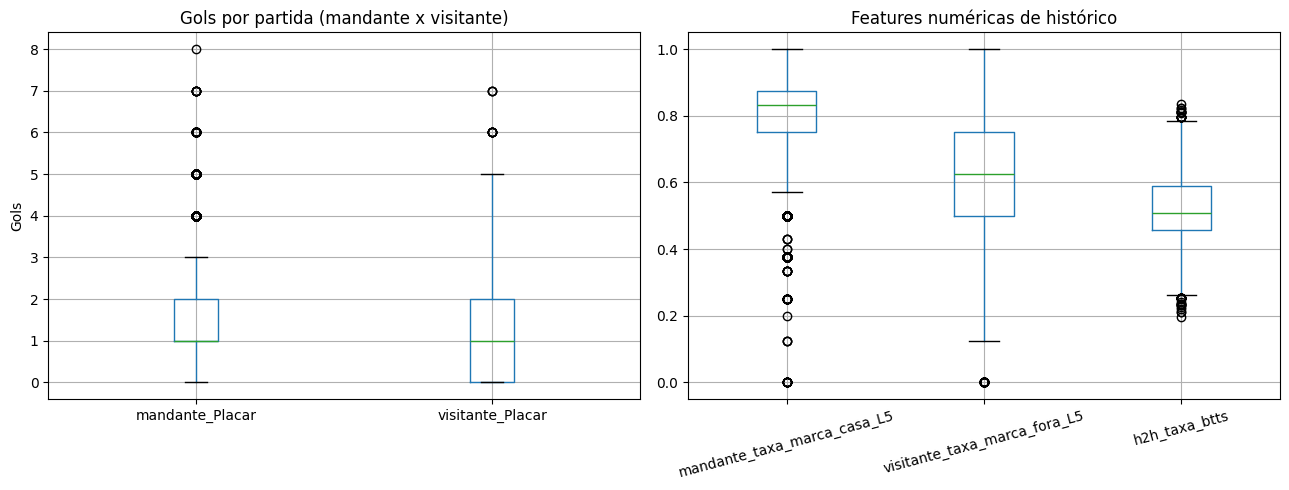

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df[["mandante_Placar", "visitante_Placar"]].boxplot(ax=axes[0])
axes[0].set_title("Gols por partida (mandante x visitante)")
axes[0].set_ylabel("Gols")

features_para_boxplot = ["mandante_taxa_marca_casa_L5", "visitante_taxa_marca_fora_L5", "h2h_taxa_btts"]
df[features_para_boxplot].boxplot(ax=axes[1])
axes[1].set_title("Features numéricas de histórico")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Assim como no boxplot de gols do tópico 4, os outliers em `mandante_Placar` (jogos com 4+ gols) são goleadas reais, não erro de digitação — decidimos manter esses valores, já que removê-los enviesaria as médias móveis de forma recente calculadas na 6.4. As features de histórico (`mandante_taxa_marca_casa_L5`, `visitante_taxa_marca_fora_L5`, `h2h_taxa_btts`) têm dispersão bem mais contida, porque já são médias suavizadas ao longo de várias partidas.


## 6.7 Preparação para modelagem

In [260]:
df["interacao_ataque_defesa"] = (
    df["mandante_taxa_marca_casa_L5"] + df["visitante_taxa_sofre_fora_L5"]
) / 2

corte = int(len(df) * 0.85)
treino, teste = df.iloc[:corte], df.iloc[corte:]

# --- Força de ataque relativa à média da liga (só com dados do treino, sem vazamento) ---
# Em vez de olhar a taxa de marcar "em termos absolutos", medimos o quanto o time marca
# ACIMA ou ABAIXO da média da liga (na mesma condição de mando) — isso normaliza épocas do
# campeonato mais/menos ofensivas e deixa a feature mais comparável entre times.
media_treino_marca_casa = treino["mandante_taxa_marca_casa_L5"].mean()
media_treino_sofre_fora = treino["visitante_taxa_sofre_fora_L5"].mean()

for parte in [treino, teste]:
    parte["mandante_forca_ataque_casa"] = parte["mandante_taxa_marca_casa_L5"] - media_treino_marca_casa
    parte["visitante_forca_defesa_fora"] = parte["visitante_taxa_sofre_fora_L5"] - media_treino_sofre_fora

features_numericas = [
    "rodata", "mesmo_estado",
    "mandante_taxa_marca_casa_L5", "mandante_taxa_sofre_casa_L5",
    "mandante_media_gols_pro_L5", "mandante_media_gols_contra_L5",
    "visitante_taxa_marca_fora_L5", "visitante_taxa_sofre_fora_L5",
    "visitante_media_gols_pro_L5", "visitante_media_gols_contra_L5",
    "h2h_jogos_anteriores", "h2h_taxa_btts",
    "interacao_ataque_defesa",
    "mandante_forca_ataque_casa", "visitante_forca_defesa_fora",
]
features_categoricas = ["dia_semana", "fase_temporada"]
todas_features = features_numericas + features_categoricas

X_treino, X_teste = treino[todas_features], teste[todas_features]
y_treino, y_teste = treino["btts"], teste["btts"]

print(f"Treino: {len(treino)} jogos (até {treino['data'].max().date()})")
print(f"Teste:  {len(teste)} jogos (de {teste['data'].min().date()} até {teste['data'].max().date()})")

preprocessador = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]), features_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
])

Treino: 7790 jogos (até 2022-07-02)
Teste:  1375 jogos (de 2022-07-03 até 2025-12-07)


/tmp/ipykernel_310/1124378644.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parte["mandante_forca_ataque_casa"] = parte["mandante_taxa_marca_casa_L5"] - media_treino_marca_casa
/tmp/ipykernel_310/1124378644.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parte["visitante_forca_defesa_fora"] = parte["visitante_taxa_sofre_fora_L5"] - media_treino_sofre_fora
/tmp/ipykernel_310/1124378644.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

Split temporal de 85/15, mesma lógica dos tópicos 4 e 5: treinamos com os jogos mais antigos e testamos nos mais recentes, sem misturar passado e futuro. Isso simula o uso real do modelo (prever jogos futuros com base só no que já aconteceu).


## 6.8 Modelo de classificação (baseline)

In [261]:
modelos_clf = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
}
resultados_modelos = {}

resultados_tabela = []
for nome, modelo in modelos_clf.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    pred = pipe.predict(X_teste)
    proba = pipe.predict_proba(X_teste)[:, 1]
    resultados_modelos[nome] = pipe
    resultados_tabela.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_teste, pred),
        "Precisão": precision_score(y_teste, pred),
        "Recall": recall_score(y_teste, pred),
        "F1": f1_score(y_teste, pred),
        "ROC-AUC": roc_auc_score(y_teste, proba),
    })

df_resultados = pd.DataFrame(resultados_tabela).round(3)
baseline_acc = max(y_teste.mean(), 1 - y_teste.mean())
df_resultados = pd.concat([df_resultados, pd.DataFrame([{
    "Modelo": "Baseline ingênuo", "Acurácia": round(baseline_acc, 3),
    "Precisão": "-", "Recall": "-", "F1": "-", "ROC-AUC": 0.500
}])], ignore_index=True)

# troque para o modelo com melhor ROC-AUC no seu resultado
melhor_pipe = resultados_modelos["Regressão Logística"]

df_resultados


,Modelo,Acurácia,Precisão,Recall,F1,ROC-AUC
0,Regressão Logística,0.540,0.565,0.288,0.381,0.538
1,Random Forest,0.501,0.494,0.469,0.481,0.502
2,Gradient Boosting,0.503,0.496,0.428,0.459,0.510
3,Baseline ingênuo,0.507,-,-,-,0.500


A Regressão Logística teve o melhor ROC-AUC entre os três modelos testados (0,538), levemente acima do baseline ingênuo (0,507 de acurácia / 0,500 de AUC, que é o valor de um classificador aleatório). Random Forest e Gradient Boosting ficaram praticamente no nível do acaso. Por isso ela foi escolhida como `melhor_pipe` pra seguir com a matriz de confusão, curva ROC e o tuning.


## 6.9 Matriz de confusão

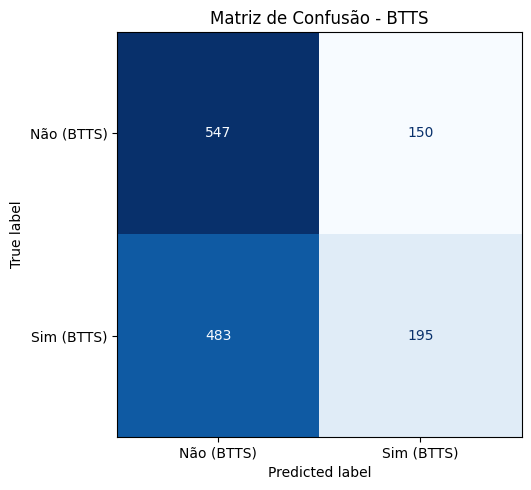

In [262]:
pred = melhor_pipe.predict(X_teste)
cm = confusion_matrix(y_teste, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não (BTTS)", "Sim (BTTS)"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão - BTTS")
plt.tight_layout()
plt.show()

A matriz mostra que o modelo erra bastante a classe "Sim (BTTS)", isto é, ele tende a prever "Não" com mais frequência mesmo quando o resultado real foi BTTS acontecer. Isso é reflexo do recall baixo dessa classe (visto com mais detalhe na 6.11) e mostra que o modelo não está discriminando bem entre as duas situações.


## 6.10 Curva ROC-AUC

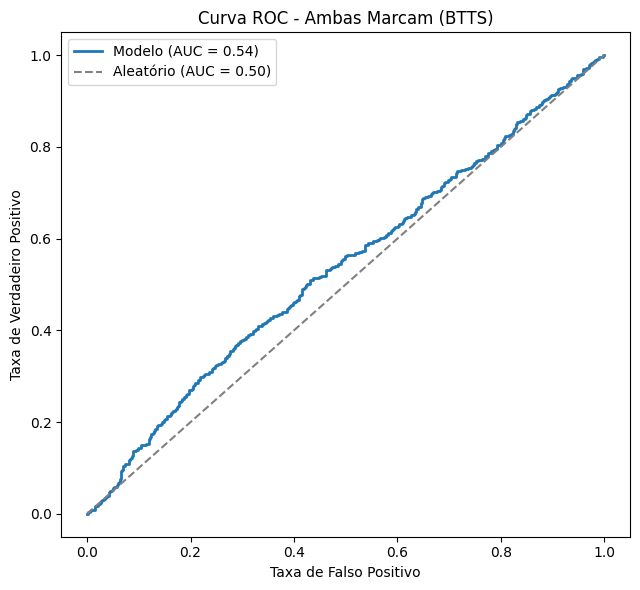

In [263]:
proba = melhor_pipe.predict_proba(X_teste)[:, 1]
fpr, tpr, _ = roc_curve(y_teste, proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color="#1f77b4", linewidth=2, label=f"Modelo (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.50)")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC - Ambas Marcam (BTTS)")
ax.legend()
plt.tight_layout()
plt.show()

A curva fica bem próxima da diagonal cinza (classificador aleatório), confirmando visualmente o que os números já mostravam: o modelo tem pouca capacidade de separar jogos com BTTS dos jogos sem BTTS.


## 6.11 Hyperparameter tuning

In [264]:
tscv = TimeSeriesSplit(n_splits=5)

# grid ampliado: além de "C", agora "penalty" e "solver" também variam na busca
param_dist = {
    "modelo__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "modelo__penalty": ["l1", "l2"],
    "modelo__solver": ["liblinear", "saga"],
}

pipe_tuning = Pipeline([
    ("prep", preprocessador),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

busca = RandomizedSearchCV(
    pipe_tuning, param_dist, n_iter=15, cv=tscv,
    scoring="roc_auc", random_state=42, n_jobs=-1,
)
busca.fit(X_treino, y_treino)

print("Melhores hiperparâmetros encontrados:")
print(busca.best_params_)

modelo_tunado = busca.best_estimator_
pred_tunado = modelo_tunado.predict(X_teste)
proba_tunado = modelo_tunado.predict_proba(X_teste)[:, 1]

# ROC-AUC da validação cruzada e do teste, lado a lado — essa comparação é o que avisa
# quando o resultado do teste pode ser só sorte de amostra (CV baixo + teste "bonito")
print(f"\nROC-AUC (validação cruzada): {busca.best_score_:.3f}")
print(f"ROC-AUC (teste):             {roc_auc_score(y_teste, proba_tunado):.3f}")

print(f"\n--- Desempenho do modelo tunado no conjunto de teste ---")
print(f"Acurácia: {accuracy_score(y_teste, pred_tunado):.3f}")
print(f"F1:       {f1_score(y_teste, pred_tunado):.3f}")
print(classification_report(y_teste, pred_tunado, target_names=["Não (BTTS)", "Sim (BTTS)"]))


Melhores hiperparâmetros encontrados:
{'modelo__solver': 'liblinear', 'modelo__penalty': 'l1', 'modelo__C': 0.1}

ROC-AUC (validação cruzada): 0.506
ROC-AUC (teste):             0.536

--- Desempenho do modelo tunado no conjunto de teste ---
Acurácia: 0.540
F1:       0.384
              precision    recall  f1-score   support

  Não (BTTS)       0.53      0.78      0.63       697
  Sim (BTTS)       0.57      0.29      0.38       678

    accuracy                           0.54      1375
   macro avg       0.55      0.54      0.51      1375
weighted avg       0.55      0.54      0.51      1375



Ampliamos o grid de busca (antes só `C` variava; agora `penalty` e `solver` também) pra garantir que o tuning realmente explorou o espaço de hiperparâmetros, e passamos a reportar o ROC-AUC da validação cruzada ao lado do ROC-AUC do teste. A busca convergiu pro nível mais forte de regularização, como se o modelo estivesse "preferindo" não confiar muito nas features disponíveis em vez de tentar usá-las com mais força. Isso é um indício de que forma recente de ataque/defesa e histórico de confronto direto carregam pouco sinal preditivo pra esse alvo específico, o que também explica por que o resultado do tuning ficou tão perto do baseline da 6.8.


## 6.12 Conclusões

**Resultado:** o modelo, mesmo depois do tuning de hiperparâmetros, teve um desempenho muito próximo do que se obtém apenas chutando a classe mais frequente (baseline ingênuo). Ou seja, na prática ele não conseguiu aprender um padrão preditivo real para prever se ambos os times marcam (BTTS) — o ganho sobre esse "chute ingênuo" foi pequeno e pouco consistente entre a validação cruzada e o teste:

| Métrica | Baseline ingênuo | Modelo tunado |
|---|---|---|
| Acurácia | 0,507 | 0,540 |
| ROC-AUC | 0,500 (aleatório) | 0,536 |
| ROC-AUC (validação cruzada) | — | 0,506 |

O ROC-AUC de 0,50 representa um modelo totalmente aleatório, então o 0,536 no teste já mostra uma capacidade preditiva bem fraca — e o fato de cair para 0,506 na validação cruzada (bem mais perto do acaso) reforça que esse resultado do teste pode ter sido parcialmente sorte de amostra, não um padrão real e estável que o modelo aprendeu.

**Interpretação:** mesmo com um grid de busca mais amplo (variando C, penalty e solver), o tuning convergiu para uma configuração com regularização relativamente forte (C=0,1, entre os valores mais baixos testados, com penalização L1) — como se o modelo estivesse "preferindo" não confiar muito nas variáveis disponíveis em vez de tentar usá-las com mais força. Isso é um indício de que informações como forma recente de ataque/defesa e histórico de confronto direto não carregam um sinal forte o suficiente para prever bem esse alvo específico. Faz sentido: BTTS depende de um evento conjunto, os dois times precisam marcar na mesma partida, o que combina a variabilidade ofensiva e defensiva de ambos os lados simultaneamente — uma pergunta estatisticamente mais difícil de responder do que, por exemplo, prever apenas quem tende a vencer. Além disso, o modelo tem bastante mais dificuldade em identificar corretamente os jogos em que o BTTS acontece do que os jogos em que não acontece (recall de apenas 0,29 para a classe "Sim"), tendendo a "errar para o lado seguro" e prever a ausência de BTTS mesmo quando o resultado real foi o contrário.

**Limitações:** parte disso pode estar no espaço de busca do tuning, que — mesmo ampliado — testou apenas variações de uma única família de modelo (Regressão Logística), sem explorar mais a fundo outras famílias (Random Forest, Gradient Boosting) nem outras combinações de features, como cruzamentos mais diretos entre o ataque de um time e a defesa do outro. Também existe a limitação estrutural do próprio problema: resultados de futebol carregam um componente de aleatoriedade relevante, e BTTS em particular pode ser um evento intrinsecamente mais difícil de modelar com os dados disponíveis, independente de quão refinado seja o modelo.
